# Indicadores de seguimiento de la evaluación del PNIE <br> Parte VI: Estimación de indicadores

Autor: Equipo de Evaluación del PNIE

Fecha de creación: 07/10/2025

Fecha de actualización: 14/10/2025

## 01. Configuración del notebook

In [1]:
# pip install xlsxwriter

In [2]:
# Importando librerias
import os
import numpy as np
import pandas as pd
# from dbfread import DBF
import re
import unicodedata
from typing import Optional
import matplotlib.pyplot as plt

In [3]:
# Directorio de trabajo
file1 = 'E:/OneDrive - Ministerio de Educación/00. Paolo/Actividades'
# file1 = 'D:/OneDrive - Ministerio de Educación/00. Paolo/Actividades'
file2 = '01. Evaluación PNIE/02. IS-PNIE'
file = file1 + '/' + file2
os.chdir(file)

In [4]:
# Configurando el formato
pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:,.1f}'.format

In [5]:
# Definiendo funciones de conteo
def unique(data, varlist):
    aux = data[varlist]
    a = aux.drop_duplicates().shape[0]
    list = " ".join(varlist)
    print(f'Number of unique values of {list} is {a:,.0f}')
    print(f'Number of records is {data.shape[0]:,.0f}')

def by_unique(data, varlist, var):
    unique(data, varlist)
    list = varlist + var
    aux = data[list]
    a = aux.drop_duplicates().value_counts(var).reset_index().\
    sort_values(by=var)
    print("\n", a)

In [6]:
# Corrección de codigos locales
def codlocal(df, oldvar, newvar):
    df[newvar] = df[oldvar].astype(str).str.zfill(6)

In [7]:
def freq(df, columna, dropna=False, decimales=1):
    """
    Genera una tabla de frecuencias absolutas, relativas (%) y totales.

    Parámetros:
    -----------
    df : DataFrame
        El DataFrame de entrada
    columna : str
        Nombre de la columna a analizar
    dropna : bool, opcional
        Si True, ignora los valores NaN. Default = False
    decimales : int, opcional
        Número de decimales para el porcentaje. Default = 2
    """
    
    # Frecuencias absolutas y relativas
    freq = df[columna].value_counts(dropna=dropna)
    rel = df[columna].value_counts(normalize=True, dropna=dropna) * 100
    
    # Construcción de la tabla
    tabla = pd.DataFrame({
        'Freq': freq,
        '(%)': rel.round(decimales)
    })
    
    # Totales
    total_freq = tabla['Freq'].sum()
    tabla.loc['TOTAL'] = [total_freq, 100]

    # Formateo: Freq con separador de miles y (%) con % explícito
    tabla['Freq'] = tabla['Freq'].apply(lambda x: f"{int(x):,}" if pd.notna(x) else x)
    tabla['(%)'] = tabla['(%)'].apply(lambda x: f"{x:.{decimales}f}%" if x != 100 else "100%")
 
    return print(tabla, '\n')

In [8]:
def crear_indicador(df, base_name, anio, summary=False):
    col_int = f"{base_name}_int"
    col_pnie = f"{base_name}_{anio}"
    df[base_name] = np.where(df[col_int].eq(1), 1,
                             np.where(df[col_pnie].eq(1) & df[col_int].ne(1), 
                                      0, np.nan))
    if summary:
        freq(df, base_name)
    return df

In [9]:
def int_mto_prev(df, base_name, anio, summary=False):
    col_int = f"{base_name}_int"
    col_pnie = f"{base_name}_{anio}"
    df[col_int] = df[col_int].fillna(0)
    df[base_name] = np.where(df[col_pnie].isna(), 
                             np.nan, np.where(df[col_int] >= df[col_pnie], 
                                              1, 0))
    if summary:
        freq(df, base_name)
    return df

In [10]:
def parche(df, base_name, anio):
    col_int = f"{base_name}_int"
    col_pnie = f"{base_name}_{anio}"
    df.loc[(df[col_pnie] == 1) & ((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 
           col_int] = 1
    df.loc[df[col_int] == 1, col_pnie] = 1
    return df

## 02. Año 2017 - PNIE

In [14]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [15]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_PNIE.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2017
df2 = df2[df2['anio_culm'] <= anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['GI5_2_int'] == 1) & (df['_existente'] == 'both'), 'GI5_2_int'] = 0
df.loc[(df['GI5_1_int'] == 1) & (df['_existente'] == 'left_only'), 
       'GI5_1_int'] = 0
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int    0.0    NaN      All
GI5_1_int                       
0.0        21056      0 21,056.0
1.0          121      0    121.0
 NaN           0  21154      NaN
 All       21177      0 42,331.0


### 2.1 Subproductos

In [16]:
# GI5
df = crear_indicador(df, 'GI5_1', 'PNIE')
freq(df, 'GI5_2_int')
df['GI5_2'] = 0

# GI4
df = parche(df, 'GI4_1', 'PNIE'); df = crear_indicador(df, 'GI4_1', 'PNIE')

df['GI4_2'] = df['GI4_2_PNIE']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', 'PNIE'); df = crear_indicador(df, 'GI4_3', 'PNIE')
df = parche(df, 'GI4_4', 'PNIE'); df = crear_indicador(df, 'GI4_4', 'PNIE')

# GI3
df = parche(df, 'GI3_1', 'PNIE'); df = crear_indicador(df, 'GI3_1', 'PNIE')
df = parche(df, 'GI3_2', 'PNIE'); df = crear_indicador(df, 'GI3_2', 'PNIE')
df = parche(df, 'GI3_3', 'PNIE'); df = crear_indicador(df, 'GI3_3', 'PNIE')
df = int_mto_prev(df, 'GI3_4', 'PNIE')

# GI2
df['GI2_1'] = df['GI2_1_PNIE']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', 'PNIE'); df = crear_indicador(df, 'GI2_2', 'PNIE')

# GI1
# VERIFICAR GI1_1
print(list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique()))
no = ['Análisis BI GR/GL del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', 'PNIE'); df = crear_indicador(df, 'GI1_1', 'PNIE')
df = parche(df, 'GI1_2', 'PNIE'); df = crear_indicador(df, 'GI1_2', 'PNIE')
df = parche(df, 'GI1_3', 'PNIE'); df = crear_indicador(df, 'GI1_3', 'PNIE')
df = parche(df, 'GI1_4', 'PNIE'); df = crear_indicador(df, 'GI1_4', 'PNIE')
df = parche(df, 'GI1_5', 'PNIE'); df = crear_indicador(df, 'GI1_5', 'PNIE')

             Freq    (%)
GI5_2_int               
0.0        21,177  50.0%
 NaN       21,154  50.0%
 TOTAL     42,331   100% 

['PRONIED-UGME-SM', 'PRONIED-UGME-SM / PRONIED-UGM-PREVENTIVO', 'PRONIED-UGME-SM / PRONIED-UGME-ME', 'PRONIED-UGME-SM / PRONIED-UGME-ME / PRONIED-UGM-PREVENTIVO', 'PRONIED-UGME-SM / PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE', 'Análisis BI GR/GL del EV-PNIE']


### 2.2 Productos

In [17]:
# GI1
df['x'] = df[['GI1_1_PNIE', 'GI1_2_PNIE', 'GI1_3_PNIE', 'GI1_4_PNIE', 
              'GI1_5_PNIE']].isna().sum(axis=1)
df['y'] = df[['GI1_1_PNIE', 'GI1_2_PNIE', 'GI1_3_PNIE', 'GI1_4_PNIE', 
              'GI1_5_PNIE']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_PNIE'].isna(), np.nan,
                   np.where(df['GI2_2_PNIE'] == 0, 1,
                            np.where((df['GI2_2_PNIE'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_PNIE', 'GI3_2_PNIE', 'GI3_3_PNIE', 'GI3_4_PNIE']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_PNIE', 'GI3_2_PNIE', 'GI3_3_PNIE', 'GI3_4_PNIE']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_PNIE', 'GI4_3_PNIE', 'GI4_4_PNIE']].isna().sum(axis=1)
df['y'] = df[['GI4_1_PNIE', 'GI4_3_PNIE', 'GI4_4_PNIE']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     38,408  90.7%
1.0      2,684   6.3%
 NaN     1,239   2.9%
 TOTAL  42,331   100% 

          Freq    (%)
GI2                  
0.0     39,755  93.9%
 NaN     2,445   5.8%
1.0        131   0.3%
 TOTAL  42,331   100% 

          Freq    (%)
GI3                  
0.0     40,038  94.6%
1.0      2,293   5.4%
 TOTAL  42,331   100% 

          Freq    (%)
GI4                  
0.0     29,889  70.6%
 NaN    12,272  29.0%
1.0        170   0.4%
 TOTAL  42,331   100% 

          Freq    (%)
GI5                  
 NaN    42,210  99.7%
1.0        121   0.3%
 TOTAL  42,331   100% 



### 2.3 Actividades

In [18]:
# ET1
df['ET1'] = df['ET1_PNIE']
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_PNIE']
freq(df, 'ET2')

          Freq    (%)
ET1                  
0.0     28,134  66.5%
1.0     12,947  30.6%
 NaN     1,250   3.0%
 TOTAL  42,331   100% 

         Freq   (%)
ET2                
NaN    42,331  100%
TOTAL  42,331  100% 



### 2.4 Resultados especificos

In [19]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2 (0% para el 2017)
df['OE2'] = df['GI5_2']
freq(df, 'OE2')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     40,971  96.8%
 NaN     1,239   2.9%
1.0        121   0.3%
 TOTAL  42,331   100% 

         Freq   (%)
OE2                
0      42,331  100%
TOTAL  42,331  100% 

          Freq    (%)
OE4                  
0.0     40,057  94.6%
 NaN     2,261   5.3%
1.0         13   0.0%
 TOTAL  42,331   100% 



### 2.5 Resultados finales

In [20]:
# Supuesto: En la línea base del PNIE no se identificaron LL.EE. con brecha
# cerrada.
df['RF1'] = df['RF1_PNIE']
df['RF2_matri'] = df['RF2_matri_PNIE']
df['matricula'] = df['matricula_PNIE']

# Para el resto de años se debe completar con brecha cerrada a los LLEE que
# tengan OE1 = 1 y OE4 = 1 o OE2 = 1 y OE4 = 1

In [21]:
df.to_csv('data/procesadas/indicadores_PNIE_TOTAL.csv', index=False)

# Seleccionando variables
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_PNIE.csv', index=False)

In [22]:
df.iloc[:, 1:-1].mean() * 100

GI1_1         1.8
GI1_2         0.5
GI1_3         0.4
GI1_4         0.0
GI1_5         0.9
GI2_1        30.7
GI2_2         0.3
GI3_1         0.3
GI3_2         0.8
GI3_3         0.3
GI3_4        25.9
GI4_1         0.4
GI4_2        99.5
GI4_3         0.3
GI4_4         0.3
GI5_1         0.7
GI5_2         0.0
GI1           6.5
GI2           0.3
GI3           5.4
GI4           0.6
GI5         100.0
ET1          31.5
ET2           NaN
OE1           0.3
OE2           0.0
OE4           0.0
RF1           0.0
RF2_matri     0.0
dtype: float64

## 03. Año 2019

In [23]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [24]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2019.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2019
df2 = df2[(df2['anio_culm'] <= anio) & (df2['anio_culm'] >= 2018)]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

max_cols = ['GI1_1_int', 'GI1_2_int', 'GI1_3_int', 'GI1_4_int', 'GI1_5_int', 
            'GI2_1_int', 'GI2_2_int', 
            'GI3_1_int', 'GI3_2_int', 'GI3_3_int',
            'GI4_1_int', 'GI4_2_int', 'GI4_3_int', 'GI4_4_int', 
            'GI5_1_int', 'GI5_2_int']

last = (
    df2.sort_values(["codlocal", "anio_culm_int"])
       .drop_duplicates("codlocal", keep="last")
       .loc[:, ["codlocal", "anio_culm_int", "GI3_4_int"]]
)
maxdf = (
    df2.groupby("codlocal", as_index=False)[max_cols]
       .max()
)
fuente = (
    df2.groupby("codlocal", as_index=False)[['CUI_int', "fuente_int"]]
       .agg(lambda s: " / ".join(pd.unique([x for x in s if pd.notna(x)])))
)
df2 = (
    last.merge(maxdf, on="codlocal", how="left")
        .merge(fuente, on="codlocal", how="left")
)
df2 = df2[['codlocal', 'anio_culm_int', 
           'GI1_1_int', 'GI1_2_int', 'GI1_3_int', 'GI1_4_int', 'GI1_5_int', 
           'GI2_1_int', 'GI2_2_int',
           'GI3_1_int', 'GI3_2_int', 'GI3_3_int', 'GI3_4_int', 
           'GI4_1_int', 'GI4_2_int', 'GI4_3_int', 'GI4_4_int', 
           'GI5_1_int', 'GI5_2_int', 'CUI_int', 'fuente_int']]

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_31336\2345500890.py:29: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  .agg(lambda s: " / ".join(pd.unique([x for x in s if pd.notna(x)])))


GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  43695 43,695.0
1.0           0    0   1714  1,714.0
 NaN       5481   59   4024      NaN
 All       5481   59      0 54,973.0


### 3.1 Subproductos

In [25]:
# GI5
df = crear_indicador(df, 'GI5_1', '2019')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2019'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2019'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2019'); df = crear_indicador(df, 'GI4_1', '2019')

df['GI4_2'] = df['GI4_2_2019']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2019'); df = crear_indicador(df, 'GI4_3', '2019')
df = parche(df, 'GI4_4', '2019'); df = crear_indicador(df, 'GI4_4', '2019')

# GI3
df = parche(df, 'GI3_1', '2019'); df = crear_indicador(df, 'GI3_1', '2019')
df = parche(df, 'GI3_2', '2019'); df = crear_indicador(df, 'GI3_2', '2019')
df = parche(df, 'GI3_3', '2019'); df = crear_indicador(df, 'GI3_3', '2019')
df = int_mto_prev(df, 'GI3_4', '2019')

# GI2
df['GI2_1'] = df['GI2_1_2019']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2019'); df = crear_indicador(df, 'GI2_2', '2019')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['Análisis FUR y emblematicos GN del EV-2019',
      'PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-2019',
      'PRONIED-UGM-PREVENTIVO / PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-2019',
      'PRONIED-UGM-PREVENTIVO / PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-2019',
      'PRONIED-UGM-PREVENTIVO / PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-2019',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-2019',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-2019 / PRONIED-UGM-PREVENTIVO',
      'Análisis BI GR/GL del EV-PNIE / PRONIED-UGM-PREVENTIVO',
      'PRONIED-UGME-ME / PRONIED-UGM-PREVENTIVO / PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / PRONIED-UGM-ACCESIBILIDAD / PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'Análisis BI GR/GL del EV-PNIE / PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'Análisis BI GR/GL del EV-PNIE', 'PRONIED-UGRD-ME']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2019'); df = crear_indicador(df, 'GI1_1', '2019')
df = parche(df, 'GI1_2', '2019'); df = crear_indicador(df, 'GI1_2', '2019')
df = parche(df, 'GI1_3', '2019'); df = crear_indicador(df, 'GI1_3', '2019')
df = parche(df, 'GI1_4', '2019'); df = crear_indicador(df, 'GI1_4', '2019')
df = parche(df, 'GI1_5', '2019'); df = crear_indicador(df, 'GI1_5', '2019')

          Freq    (%)
GI5_1                
 NaN    32,342  58.8%
0.0     18,760  34.1%
1.0      3,871   7.0%
 TOTAL  54,973   100% 

          Freq    (%)
GI5_2                
 NaN    49,422  89.9%
0.0      5,428   9.9%
1.0        123   0.2%
 TOTAL  54,973   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  18760 18,760.0
1.0       0    0   3871  3,871.0
 NaN   5428  123  26791      NaN
 All   5428  123      0 54,973.0


### 3.2 Productos

In [26]:
# GI1
df['x'] = df[['GI1_1_2019', 'GI1_2_2019', 'GI1_3_2019', 'GI1_4_2019', 
              'GI1_5_2019']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2019', 'GI1_2_2019', 'GI1_3_2019', 'GI1_4_2019', 
              'GI1_5_2019']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2019'].isna(), np.nan,
                   np.where(df['GI2_2_2019'] == 0, 1,
                            np.where((df['GI2_2_2019'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2019', 'GI3_2_2019', 'GI3_3_2019', 'GI3_4_2019']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2019', 'GI3_2_2019', 'GI3_3_2019', 'GI3_4_2019']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2019', 'GI4_3_2019', 'GI4_4_2019']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2019', 'GI4_3_2019', 'GI4_4_2019']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     40,100  72.9%
1.0      7,699  14.0%
 NaN     7,174  13.1%
 TOTAL  54,973   100% 

          Freq    (%)
GI2                  
 NaN    29,103  52.9%
0.0     21,687  39.5%
1.0      4,183   7.6%
 TOTAL  54,973   100% 

          Freq    (%)
GI3                  
0.0     42,808  77.9%
 NaN     7,753  14.1%
1.0      4,412   8.0%
 TOTAL  54,973   100% 

          Freq    (%)
GI4                  
 NaN    28,691  52.2%
0.0     22,163  40.3%
1.0      4,119   7.5%
 TOTAL  54,973   100% 

          Freq    (%)
GI5                  
 NaN    50,979  92.7%
1.0      3,994   7.3%
 TOTAL  54,973   100% 



### 3.3 Actividades

In [27]:
# ET1
df['ET1'] = df['ET1_2019']
df.loc[(df['ET1'] != 1) & (df['finfo_2019'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2019']
df.loc[(df['ET2'] != 1) & (df['finfo_2019'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
0.0     26,008  47.3%
 NaN    15,614  28.4%
1.0     13,351  24.3%
 TOTAL  54,973   100% 

          Freq    (%)
ET2                  
 NaN    51,076  92.9%
0.0      3,566   6.5%
1.0        331   0.6%
 TOTAL  54,973   100% 



### 3.4 Resultados especificos

In [28]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2019'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     46,896  85.3%
 NaN     4,206   7.7%
1.0      3,871   7.0%
 TOTAL  54,973   100% 

count     123.0
mean       94.0
std       226.0
min         1.0
25%        12.0
50%        29.0
75%        86.0
max     2,168.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    29,420  53.5%
0.0     24,521  44.6%
1.0      1,032   1.9%
 TOTAL  54,973   100% 



### 3.5 Resultados finales

In [29]:
df['RF1'] = df['RF1_2019']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2019']
df[['matricula_2019', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      52,013  94.6%
1       2,960   5.4%
TOTAL  54,973   100% 



matricula_2019   6,242,216.0
RF2_matri          617,804.0
dtype: float64

In [30]:
df.to_csv('data/procesadas/indicadores_2019_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2019': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2019.csv', index=False)

In [31]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            8.8
GI1_2            8.3
GI1_3            8.8
GI1_4            5.9
GI1_5           14.3
GI2_1           50.9
GI2_2           10.2
GI3_1            9.4
GI3_2            9.6
GI3_3            9.2
GI3_4           54.6
GI4_1            7.8
GI4_2           86.1
GI4_3            8.8
GI4_4            9.7
GI5_1           17.1
GI5_2            2.2
GI1             16.1
GI2             16.2
GI3              9.3
GI4             15.7
GI5            100.0
ET1             33.9
ET2              8.5
OE1              7.6
OE2          9,401.6
OE4              4.0
RF1              5.4
RF2_matri   20,871.8
dtype: float64

## 04. Año 2020

In [32]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [33]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2020.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2020
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  43627 43,627.0
1.0           0    0    698    698.0
 NaN       5498   36   5199      NaN
 All       5498   36      0 55,058.0


### 4.1 Subproductos

In [34]:
# GI5
df = crear_indicador(df, 'GI5_1', '2020')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2020'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2020'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2020'); df = crear_indicador(df, 'GI4_1', '2020')

df['GI4_2'] = df['GI4_2_2020']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2020'); df = crear_indicador(df, 'GI4_3', '2020')
df = parche(df, 'GI4_4', '2020'); df = crear_indicador(df, 'GI4_4', '2020')

# GI3
df = parche(df, 'GI3_1', '2020'); df = crear_indicador(df, 'GI3_1', '2020')
df = parche(df, 'GI3_2', '2020'); df = crear_indicador(df, 'GI3_2', '2020')
df = parche(df, 'GI3_3', '2020'); df = crear_indicador(df, 'GI3_3', '2020')
df = int_mto_prev(df, 'GI3_4', '2020')

# GI2
df['GI2_1'] = df['GI2_1_2020']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2020'); df = crear_indicador(df, 'GI2_2', '2020')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'Análisis BI GN del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2020'); df = crear_indicador(df, 'GI1_1', '2020')
df = parche(df, 'GI1_2', '2020'); df = crear_indicador(df, 'GI1_2', '2020')
df = parche(df, 'GI1_3', '2020'); df = crear_indicador(df, 'GI1_3', '2020')
df = parche(df, 'GI1_4', '2020'); df = crear_indicador(df, 'GI1_4', '2020')
df = parche(df, 'GI1_5', '2020'); df = crear_indicador(df, 'GI1_5', '2020')

          Freq    (%)
GI5_1                
 NaN    32,702  59.4%
0.0     18,834  34.2%
1.0      3,522   6.4%
 TOTAL  55,058   100% 

          Freq    (%)
GI5_2                
 NaN    49,493  89.9%
0.0      5,418   9.8%
1.0        147   0.3%
 TOTAL  55,058   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  18834 18,834.0
1.0       0    0   3522  3,522.0
 NaN   5418  147  27137      NaN
 All   5418  147      0 55,058.0


### 4.2 Productos

In [35]:
# GI1
df['x'] = df[['GI1_1_2020', 'GI1_2_2020', 'GI1_3_2020', 'GI1_4_2020', 
              'GI1_5_2020']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2020', 'GI1_2_2020', 'GI1_3_2020', 'GI1_4_2020', 
              'GI1_5_2020']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2020'].isna(), np.nan,
                   np.where(df['GI2_2_2020'] == 0, 1,
                            np.where((df['GI2_2_2020'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2020', 'GI3_2_2020', 'GI3_3_2020', 'GI3_4_2020']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2020', 'GI3_2_2020', 'GI3_3_2020', 'GI3_4_2020']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2020', 'GI4_3_2020', 'GI4_4_2020']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2020', 'GI4_3_2020', 'GI4_4_2020']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     40,471  73.5%
1.0      8,779  15.9%
 NaN     5,808  10.5%
 TOTAL  55,058   100% 

          Freq    (%)
GI2                  
 NaN    28,731  52.2%
0.0     22,456  40.8%
1.0      3,871   7.0%
 TOTAL  55,058   100% 

          Freq    (%)
GI3                  
0.0     43,477  79.0%
 NaN     7,782  14.1%
1.0      3,799   6.9%
 TOTAL  55,058   100% 

          Freq    (%)
GI4                  
 NaN    28,636  52.0%
0.0     22,562  41.0%
1.0      3,860   7.0%
 TOTAL  55,058   100% 

          Freq    (%)
GI5                  
 NaN    51,389  93.3%
1.0      3,669   6.7%
 TOTAL  55,058   100% 



### 4.3 Actividades

In [36]:
# ET1
df['ET1'] = df['ET1_2020']
df.loc[(df['ET1'] != 1) & (df['finfo_2020'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2020']
df.loc[(df['ET2'] != 1) & (df['finfo_2020'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
 NaN    29,401  53.4%
1.0     13,586  24.7%
0.0     12,071  21.9%
 TOTAL  55,058   100% 

          Freq    (%)
ET2                  
 NaN    54,542  99.1%
1.0        384   0.7%
0.0        132   0.2%
 TOTAL  55,058   100% 



### 4.4 Resultados especificos

In [37]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2020'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     47,971  87.1%
 NaN     3,565   6.5%
1.0      3,522   6.4%
 TOTAL  55,058   100% 

count     147.0
mean      107.6
std       263.2
min         4.0
25%        14.5
50%        35.0
75%        79.0
max     2,304.0
Name: OE2, dtype: float64 



          Freq    (%)
OE4                  
 NaN    29,260  53.1%
0.0     24,259  44.1%
1.0      1,539   2.8%
 TOTAL  55,058   100% 



### 4.5 Resultados finales

In [38]:
df['RF1'] = df['RF1_2020']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2020']
df[['matricula_2020', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,719  93.9%
1       3,339   6.1%
TOTAL  55,058   100% 



matricula_2020   6,585,668.0
RF2_matri          798,948.0
dtype: float64

In [39]:
df.to_csv('data/procesadas/indicadores_2020_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2020': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2020.csv', index=False)

In [40]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            6.8
GI1_2            8.3
GI1_3            7.7
GI1_4            4.7
GI1_5           11.5
GI2_1           55.2
GI2_2            8.6
GI3_1            7.8
GI3_2            7.4
GI3_3            8.0
GI3_4           66.3
GI4_1            7.2
GI4_2           89.0
GI4_3            8.3
GI4_4            8.4
GI5_1           15.8
GI5_2            2.6
GI1             17.8
GI2             14.7
GI3              8.0
GI4             14.6
GI5            100.0
ET1             53.0
ET2             74.4
OE1              6.8
OE2         10,758.5
OE4              6.0
RF1              6.1
RF2_matri   23,927.8
dtype: float64

## 05. Año 2021

In [41]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [42]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2021.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2021
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  45854 45,854.0
1.0           0    0    715    715.0
 NaN       6270   38   2334      NaN
 All       6270   38      0 55,211.0


### 5.1 Subproductos

In [43]:
# GI5
df = crear_indicador(df, 'GI5_1', '2021')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2021'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2021'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2021'); df = crear_indicador(df, 'GI4_1', '2021')

df['GI4_2'] = df['GI4_2_2021']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2021'); df = crear_indicador(df, 'GI4_3', '2021')
df = parche(df, 'GI4_4', '2021'); df = crear_indicador(df, 'GI4_4', '2021')

# GI3
df = parche(df, 'GI3_1', '2021'); df = crear_indicador(df, 'GI3_1', '2021')
df = parche(df, 'GI3_2', '2021'); df = crear_indicador(df, 'GI3_2', '2021')
df = parche(df, 'GI3_3', '2021'); df = crear_indicador(df, 'GI3_3', '2021')
df = int_mto_prev(df, 'GI3_4', '2021')

# GI2
df['GI2_1'] = df['GI2_1_2021']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2021'); df = crear_indicador(df, 'GI2_2', '2021')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-PNIE / Análisis IOARR GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-PNIE',
      'Análisis FUR y emblematicos GN del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'PRONIED-UGME-ME / PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGRD-ME / PRONIED-UGM-PREVENTIVO / Análisis FUR y emblematicos GN del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2021'); df = crear_indicador(df, 'GI1_1', '2021')
df = parche(df, 'GI1_2', '2021'); df = crear_indicador(df, 'GI1_2', '2021')
df = parche(df, 'GI1_3', '2021'); df = crear_indicador(df, 'GI1_3', '2021')
df = parche(df, 'GI1_4', '2021'); df = crear_indicador(df, 'GI1_4', '2021')
df = parche(df, 'GI1_5', '2021'); df = crear_indicador(df, 'GI1_5', '2021')

          Freq    (%)
GI5_1                
 NaN    31,596  57.2%
0.0     19,345  35.0%
1.0      4,270   7.7%
 TOTAL  55,211   100% 

          Freq    (%)
GI5_2                
 NaN    48,897  88.6%
0.0      6,101  11.1%
1.0        213   0.4%
 TOTAL  55,211   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  19345 19,345.0
1.0       0    0   4270  4,270.0
 NaN   6101  213  25282      NaN
 All   6101  213      0 55,211.0


### 5.2 Productos

In [44]:
# GI1
df['x'] = df[['GI1_1_2021', 'GI1_2_2021', 'GI1_3_2021', 'GI1_4_2021', 
              'GI1_5_2021']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2021', 'GI1_2_2021', 'GI1_3_2021', 'GI1_4_2021', 
              'GI1_5_2021']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2021'].isna(), np.nan,
                   np.where(df['GI2_2_2021'] == 0, 1,
                            np.where((df['GI2_2_2021'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2021', 'GI3_2_2021', 'GI3_3_2021', 'GI3_4_2021']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2021', 'GI3_2_2021', 'GI3_3_2021', 'GI3_4_2021']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2021', 'GI4_3_2021', 'GI4_4_2021']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2021', 'GI4_3_2021', 'GI4_4_2021']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     39,217  71.0%
1.0     10,070  18.2%
 NaN     5,924  10.7%
 TOTAL  55,211   100% 

          Freq    (%)
GI2                  
 NaN    29,343  53.1%
0.0     21,202  38.4%
1.0      4,666   8.5%
 TOTAL  55,211   100% 

          Freq    (%)
GI3                  
0.0     43,477  78.7%
 NaN     7,021  12.7%
1.0      4,713   8.5%
 TOTAL  55,211   100% 

          Freq    (%)
GI4                  
 NaN    28,610  51.8%
0.0     21,855  39.6%
1.0      4,746   8.6%
 TOTAL  55,211   100% 

          Freq    (%)
GI5                  
 NaN    50,728  91.9%
1.0      4,483   8.1%
 TOTAL  55,211   100% 



### 5.3 Actividades

In [45]:
# ET1
df['ET1'] = df['ET1_2021']
df.loc[(df['ET1'] != 1) & (df['finfo_2021'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2021']
df.loc[(df['ET2'] != 1) & (df['finfo_2021'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
 NaN    25,876  46.9%
1.0     19,340  35.0%
0.0      9,995  18.1%
 TOTAL  55,211   100% 

          Freq    (%)
ET2                  
 NaN    54,128  98.0%
1.0        977   1.8%
0.0        106   0.2%
 TOTAL  55,211   100% 



### 5.4 Resultados especificos

In [46]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2021'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     48,034  87.0%
1.0      4,270   7.7%
 NaN     2,907   5.3%
 TOTAL  55,211   100% 

count     213.0
mean      108.2
std       264.4
min         4.0
25%        18.0
50%        43.0
75%        83.0
max     2,303.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    29,352  53.2%
0.0     24,714  44.8%
1.0      1,145   2.1%
 TOTAL  55,211   100% 



### 5.5 Resultados finales

In [47]:
df['RF1'] = df['RF1_2021']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2021']
df[['matricula_2021', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,093  92.5%
1       4,118   7.5%
TOTAL  55,211   100% 



matricula_2021   6,743,853.0
RF2_matri          955,774.0
dtype: float64

In [48]:
df.to_csv('data/procesadas/indicadores_2021_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2021': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2021.csv', index=False)

In [49]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            8.8
GI1_2           12.1
GI1_3            9.0
GI1_4            5.6
GI1_5           15.8
GI2_1           38.6
GI2_2           10.9
GI3_1            9.8
GI3_2            9.2
GI3_3            9.9
GI3_4           51.3
GI4_1            9.7
GI4_2           80.8
GI4_3           10.4
GI4_4           10.5
GI5_1           18.1
GI5_2            3.4
GI1             20.4
GI2             18.0
GI3              9.8
GI4             17.8
GI5            100.0
ET1             65.9
ET2             90.2
OE1              8.2
OE2         10,822.5
OE4              4.4
RF1              7.5
RF2_matri   23,209.7
dtype: float64

## 06. Año 2022

In [50]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [51]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2022.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2022
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  45023 45,023.0
1.0           0    0   1457  1,457.0
 NaN       6320  116   2388      NaN
 All       6320  116      0 55,304.0


### 6.1 Subproductos

In [52]:
# GI5
df = crear_indicador(df, 'GI5_1', '2022')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2022'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2022'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2022'); df = crear_indicador(df, 'GI4_1', '2022')

df['GI4_2'] = df['GI4_2_2022']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2022'); df = crear_indicador(df, 'GI4_3', '2022')
df = parche(df, 'GI4_4', '2022'); df = crear_indicador(df, 'GI4_4', '2022')

# GI3
df = parche(df, 'GI3_1', '2022'); df = crear_indicador(df, 'GI3_1', '2022')
df = parche(df, 'GI3_2', '2022'); df = crear_indicador(df, 'GI3_2', '2022')
df = parche(df, 'GI3_3', '2022'); df = crear_indicador(df, 'GI3_3', '2022')
df = int_mto_prev(df, 'GI3_4', '2022')

# GI2
df['GI2_1'] = df['GI2_1_2022']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2022'); df = crear_indicador(df, 'GI2_2', '2022')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis IOARR GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGRD-ME / PRONIED-UGM-PREVENTIVO']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2022'); df = crear_indicador(df, 'GI1_1', '2022')
df = parche(df, 'GI1_2', '2022'); df = crear_indicador(df, 'GI1_2', '2022')
df = parche(df, 'GI1_3', '2022'); df = crear_indicador(df, 'GI1_3', '2022')
df = parche(df, 'GI1_4', '2022'); df = crear_indicador(df, 'GI1_4', '2022')
df = parche(df, 'GI1_5', '2022'); df = crear_indicador(df, 'GI1_5', '2022')

          Freq    (%)
GI5_1                
 NaN    25,730  46.5%
0.0     25,151  45.5%
1.0      4,423   8.0%
 TOTAL  55,304   100% 

          Freq    (%)
GI5_2                
 NaN    48,859  88.3%
0.0      6,173  11.2%
1.0        272   0.5%
 TOTAL  55,304   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  25151 25,151.0
1.0       0    0   4423  4,423.0
 NaN   6173  272  19285      NaN
 All   6173  272      0 55,304.0


### 6.2 Productos

In [53]:
# GI1
df['x'] = df[['GI1_1_2022', 'GI1_2_2022', 'GI1_3_2022', 'GI1_4_2022', 
              'GI1_5_2022']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2022', 'GI1_2_2022', 'GI1_3_2022', 'GI1_4_2022', 
              'GI1_5_2022']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2022'].isna(), np.nan,
                   np.where(df['GI2_2_2022'] == 0, 1,
                            np.where((df['GI2_2_2022'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2022', 'GI3_2_2022', 'GI3_3_2022', 'GI3_4_2022']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2022', 'GI3_2_2022', 'GI3_3_2022', 'GI3_4_2022']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2022', 'GI4_3_2022', 'GI4_4_2022']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2022', 'GI4_3_2022', 'GI4_4_2022']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     45,345  82.0%
1.0      7,691  13.9%
 NaN     2,268   4.1%
 TOTAL  55,304   100% 

          Freq    (%)
GI2                  
 NaN    30,545  55.2%
0.0     19,904  36.0%
1.0      4,855   8.8%
 TOTAL  55,304   100% 

          Freq    (%)
GI3                  
0.0     50,147  90.7%
1.0      4,925   8.9%
 NaN       232   0.4%
 TOTAL  55,304   100% 

          Freq    (%)
GI4                  
 NaN    30,361  54.9%
0.0     19,944  36.1%
1.0      4,999   9.0%
 TOTAL  55,304   100% 

          Freq    (%)
GI5                  
 NaN    50,609  91.5%
1.0      4,695   8.5%
 TOTAL  55,304   100% 



### 6.3 Actividades

In [54]:
# ET1
df['ET1'] = df['ET1_2022']
df.loc[(df['ET1'] != 1) & (df['finfo_2022'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2022']
df.loc[(df['ET2'] != 1) & (df['finfo_2022'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
 NaN    25,301  45.7%
1.0     19,658  35.5%
0.0     10,345  18.7%
 TOTAL  55,304   100% 

          Freq    (%)
ET2                  
 NaN    53,937  97.5%
1.0      1,163   2.1%
0.0        204   0.4%
 TOTAL  55,304   100% 



### 6.4 Resultados especificos

In [55]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2022'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     50,768  91.8%
1.0      4,423   8.0%
 NaN       113   0.2%
 TOTAL  55,304   100% 

count     272.0
mean      101.0
std       199.1
min         2.0
25%        17.0
50%        43.0
75%        92.0
max     1,704.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    30,412  55.0%
0.0     23,947  43.3%
1.0        945   1.7%
 TOTAL  55,304   100% 



### 6.5 Resultados finales

In [56]:
df['RF1'] = df['RF1_2022']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2022']
df[['matricula_2022', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,100  92.4%
1       4,204   7.6%
TOTAL  55,304   100% 



matricula_2022   6,569,996.0
RF2_matri          836,341.0
dtype: float64

In [57]:
df.to_csv('data/procesadas/indicadores_2022_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2022': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2022.csv', index=False)

In [58]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            6.2
GI1_2           10.2
GI1_3            9.0
GI1_4            3.6
GI1_5           17.4
GI2_1           41.6
GI2_2           15.1
GI3_1           13.8
GI3_2            8.4
GI3_3           14.6
GI3_4           45.1
GI4_1           11.6
GI4_2           83.7
GI4_3           13.6
GI4_4           13.3
GI5_1           15.0
GI5_2            4.2
GI1             14.5
GI2             19.6
GI3              8.9
GI4             20.0
GI5            100.0
ET1             65.5
ET2             85.1
OE1              8.0
OE2         10,101.5
OE4              3.8
RF1              7.6
RF2_matri   19,893.9
dtype: float64

## 07. Año 2023

In [59]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [60]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2023.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2023
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  46207 46,207.0
1.0           0    0    660    660.0
 NaN       6652   65   1774      NaN
 All       6652   65      0 55,358.0


### 7.1 Subproductos

In [61]:
# GI5
df = crear_indicador(df, 'GI5_1', '2023')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2023'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2023'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2023'); df = crear_indicador(df, 'GI4_1', '2023')

df['GI4_2'] = df['GI4_2_2023']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2023'); df = crear_indicador(df, 'GI4_3', '2023')
df = parche(df, 'GI4_4', '2023'); df = crear_indicador(df, 'GI4_4', '2023')

# GI3
df = parche(df, 'GI3_1', '2023'); df = crear_indicador(df, 'GI3_1', '2023')
df = parche(df, 'GI3_2', '2023'); df = crear_indicador(df, 'GI3_2', '2023')
df = parche(df, 'GI3_3', '2023'); df = crear_indicador(df, 'GI3_3', '2023')
df = int_mto_prev(df, 'GI3_4', '2023')

# GI2
df['GI2_1'] = df['GI2_1_2023']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2023'); df = crear_indicador(df, 'GI2_2', '2023')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2023'); df = crear_indicador(df, 'GI1_1', '2023')
df = parche(df, 'GI1_2', '2023'); df = crear_indicador(df, 'GI1_2', '2023')
df = parche(df, 'GI1_3', '2023'); df = crear_indicador(df, 'GI1_3', '2023')
df = parche(df, 'GI1_4', '2023'); df = crear_indicador(df, 'GI1_4', '2023')
df = parche(df, 'GI1_5', '2023'); df = crear_indicador(df, 'GI1_5', '2023')

          Freq    (%)
GI5_1                
0.0     25,645  46.3%
 NaN    25,458  46.0%
1.0      4,255   7.7%
 TOTAL  55,358   100% 

          Freq    (%)
GI5_2                
 NaN    48,630  87.8%
0.0      6,425  11.6%
1.0        303   0.5%
 TOTAL  55,358   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  25645 25,645.0
1.0       0    0   4255  4,255.0
 NaN   6425  303  18730      NaN
 All   6425  303      0 55,358.0


### 7.2 Productos

In [62]:
# GI1
df['x'] = df[['GI1_1_2023', 'GI1_2_2023', 'GI1_3_2023', 'GI1_4_2023', 
              'GI1_5_2023']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2023', 'GI1_2_2023', 'GI1_3_2023', 'GI1_4_2023', 
              'GI1_5_2023']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2023'].isna(), np.nan,
                   np.where(df['GI2_2_2023'] == 0, 1,
                            np.where((df['GI2_2_2023'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2023', 'GI3_2_2023', 'GI3_3_2023', 'GI3_4_2023']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2023', 'GI3_2_2023', 'GI3_3_2023', 'GI3_4_2023']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2023', 'GI4_3_2023', 'GI4_4_2023']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2023', 'GI4_3_2023', 'GI4_4_2023']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     45,886  82.9%
1.0      7,174  13.0%
 NaN     2,298   4.2%
 TOTAL  55,358   100% 

          Freq    (%)
GI2                  
 NaN    30,895  55.8%
0.0     19,850  35.9%
1.0      4,613   8.3%
 TOTAL  55,358   100% 

          Freq    (%)
GI3                  
0.0     48,205  87.1%
1.0      7,040  12.7%
 NaN       113   0.2%
 TOTAL  55,358   100% 

          Freq    (%)
GI4                  
 NaN    30,871  55.8%
0.0     19,520  35.3%
1.0      4,967   9.0%
 TOTAL  55,358   100% 

          Freq    (%)
GI5                  
 NaN    50,800  91.8%
1.0      4,558   8.2%
 TOTAL  55,358   100% 



### 7.3 Actividades

In [63]:
# ET1
df['ET1'] = df['ET1_2023']
df.loc[(df['ET1'] != 1) & (df['finfo_2023'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2023']
df.loc[(df['ET2'] != 1) & (df['finfo_2023'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
 NaN    23,712  42.8%
1.0     20,313  36.7%
0.0     11,333  20.5%
 TOTAL  55,358   100% 

          Freq    (%)
ET2                  
 NaN    53,492  96.6%
1.0      1,322   2.4%
0.0        544   1.0%
 TOTAL  55,358   100% 



### 7.4 Resultados especificos

In [64]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2023'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     51,034  92.2%
1.0      4,255   7.7%
 NaN        69   0.1%
 TOTAL  55,358   100% 

count     303.0
mean       91.1
std       174.3
min         1.0
25%        16.0
50%        39.0
75%        82.5
max     1,537.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    31,062  56.1%
0.0     23,480  42.4%
1.0        816   1.5%
 TOTAL  55,358   100% 



### 7.5 Resultados finales

In [65]:
df['RF1'] = df['RF1_2023']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2023']
df[['matricula_2023', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,197  92.5%
1       4,161   7.5%
TOTAL  55,358   100% 



matricula_2023   6,529,623.0
RF2_matri          824,499.0
dtype: float64

In [66]:
df.to_csv('data/procesadas/indicadores_2023_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2023': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2023.csv', index=False)

In [67]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            4.7
GI1_2            9.7
GI1_3            8.7
GI1_4            2.9
GI1_5           15.9
GI2_1           39.1
GI2_2           15.8
GI3_1           14.3
GI3_2           14.7
GI3_3           15.9
GI3_4           42.4
GI4_1           10.0
GI4_2           82.9
GI4_3           14.3
GI4_4           13.6
GI5_1           14.2
GI5_2            4.5
GI1             13.5
GI2             18.9
GI3             12.7
GI4             20.3
GI5            100.0
ET1             64.2
ET2             70.8
OE1              7.7
OE2          9,111.2
OE4              3.4
RF1              7.5
RF2_matri   19,814.9
dtype: float64

## 08. Año 2024

In [68]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [69]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2024.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2024
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  45534 45,534.0
1.0           0    0   1047  1,047.0
 NaN       6908   82   1854      NaN
 All       6908   82      0 55,425.0


### 8.1 Subproductos

In [70]:
# GI5
df = crear_indicador(df, 'GI5_1', '2024')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2024'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2024'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2024'); df = crear_indicador(df, 'GI4_1', '2024')

df['GI4_2'] = df['GI4_2_2024']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2024'); df = crear_indicador(df, 'GI4_3', '2024')
df = parche(df, 'GI4_4', '2024'); df = crear_indicador(df, 'GI4_4', '2024')

# GI3
df = parche(df, 'GI3_1', '2024'); df = crear_indicador(df, 'GI3_1', '2024')
df = parche(df, 'GI3_2', '2024'); df = crear_indicador(df, 'GI3_2', '2024')
df = parche(df, 'GI3_3', '2024'); df = crear_indicador(df, 'GI3_3', '2024')
df = int_mto_prev(df, 'GI3_4', '2024')

# GI2
df['GI2_1'] = df['GI2_1_2024']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2024'); df = crear_indicador(df, 'GI2_2', '2024')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis IOARR GR/GL del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2024'); df = crear_indicador(df, 'GI1_1', '2024')
df = parche(df, 'GI1_2', '2024'); df = crear_indicador(df, 'GI1_2', '2024')
df = parche(df, 'GI1_3', '2024'); df = crear_indicador(df, 'GI1_3', '2024')
df = parche(df, 'GI1_4', '2024'); df = crear_indicador(df, 'GI1_4', '2024')
df = parche(df, 'GI1_5', '2024'); df = crear_indicador(df, 'GI1_5', '2024')

          Freq    (%)
GI5_1                
 NaN    28,332  51.1%
0.0     22,901  41.3%
1.0      4,192   7.6%
 TOTAL  55,425   100% 

          Freq    (%)
GI5_2                
 NaN    48,425  87.4%
0.0      6,654  12.0%
1.0        346   0.6%
 TOTAL  55,425   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  22901 22,901.0
1.0       0    0   4192  4,192.0
 NaN   6654  346  21332      NaN
 All   6654  346      0 55,425.0


### 8.3 Productos

In [71]:
# GI1
df['x'] = df[['GI1_1_2024', 'GI1_2_2024', 'GI1_3_2024', 'GI1_4_2024', 
              'GI1_5_2024']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2024', 'GI1_2_2024', 'GI1_3_2024', 'GI1_4_2024', 
              'GI1_5_2024']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2024'].isna(), np.nan,
                   np.where(df['GI2_2_2024'] == 0, 1,
                            np.where((df['GI2_2_2024'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2024', 'GI3_2_2024', 'GI3_3_2024', 'GI3_4_2024']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2024', 'GI3_2_2024', 'GI3_3_2024', 'GI3_4_2024']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2024', 'GI4_3_2024', 'GI4_4_2024']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2024', 'GI4_3_2024', 'GI4_4_2024']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     44,346  80.0%
1.0      7,954  14.4%
 NaN     3,125   5.6%
 TOTAL  55,425   100% 

          Freq    (%)
GI2                  
 NaN    28,027  50.6%
0.0     22,714  41.0%
1.0      4,684   8.5%
 TOTAL  55,425   100% 

          Freq    (%)
GI3                  
0.0     49,874  90.0%
1.0      5,425   9.8%
 NaN       126   0.2%
 TOTAL  55,425   100% 

          Freq    (%)
GI4                  
 NaN    27,976  50.5%
0.0     22,370  40.4%
1.0      5,079   9.2%
 TOTAL  55,425   100% 

          Freq    (%)
GI5                  
 NaN    50,887  91.8%
1.0      4,538   8.2%
 TOTAL  55,425   100% 



### 8.3 Actividades

In [72]:
# ET1
df['ET1'] = df['ET1_2024']
df.loc[(df['ET1'] != 1) & (df['finfo_2024'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2024']
df.loc[(df['ET2'] != 1) & (df['finfo_2024'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
0.0     23,435  42.3%
1.0     21,386  38.6%
 NaN    10,604  19.1%
 TOTAL  55,425   100% 

          Freq    (%)
ET2                  
 NaN    49,189  88.7%
0.0      4,703   8.5%
1.0      1,533   2.8%
 TOTAL  55,425   100% 



### 8.4 Resultados especificos

In [73]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2024'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     51,170  92.3%
1.0      4,192   7.6%
 NaN        63   0.1%
 TOTAL  55,425   100% 

count     346.0
mean       95.1
std       175.9
min         1.0
25%        16.0
50%        38.0
75%        83.8
max     1,669.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    28,116  50.7%
0.0     26,957  48.6%
1.0        352   0.6%
 TOTAL  55,425   100% 



### 8.5 Resultados finales

In [74]:
df['RF1'] = df['RF1_2024']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2024']
df[['matricula_2024', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,534  93.0%
1       3,891   7.0%
TOTAL  55,425   100% 



matricula_2024   6,430,260.0
RF2_matri          894,807.0
dtype: float64

In [75]:
df.to_csv('data/procesadas/indicadores_2024_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2024': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2024.csv', index=False)

In [76]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            3.9
GI1_2            9.2
GI1_3            7.5
GI1_4            2.4
GI1_5           20.4
GI2_1           44.0
GI2_2           15.0
GI3_1           13.8
GI3_2           10.1
GI3_3           15.0
GI3_4           30.6
GI4_1            8.6
GI4_2           86.9
GI4_3           13.2
GI4_4           12.9
GI5_1           15.5
GI5_2            4.9
GI1             15.2
GI2             17.1
GI3              9.8
GI4             18.5
GI5            100.0
ET1             47.7
ET2             24.6
OE1              7.6
OE2          9,509.5
OE4              1.3
RF1              7.0
RF2_matri   22,996.8
dtype: float64

## 09. Año 2025

In [77]:
# Obteniendo información sobre LLEE nuevos y existente
exis = pd.read_csv('data/procesadas/llee_existentes.csv', 
                   dtype={'codlocal': str})

In [78]:
# Importando datos
df1 = pd.read_csv('data/procesadas/necint_2025.csv', dtype={'codlocal': str})
df2 = pd.read_csv('data/procesadas/intervenciones.csv', 
                  dtype={'codlocal': str, 'CUI': str})

# Intervenciones hasta el año de analisis
anio = 2025
df2 = df2[df2['anio_culm'] == anio]
sufix = 'int'
df2.rename(columns={c: f'{c}_{sufix}' for c in df2.columns[1:]}, inplace=True)

# Uniendo necesidades e intervenciones
df = pd.merge(df1, df2, on='codlocal', how='left')
df = pd.merge(df, exis, on='codlocal', how='left', indicator='_existente')

# Correccion en GI5_2_int
df.loc[(df['_existente'] == 'left_only'), 'GI5_1_int'] = np.nan
df.loc[(df['_existente'] == 'both'), 'GI5_2_int'] = np.nan
print(pd.crosstab(df['GI5_1_int'], df['GI5_2_int'], dropna=False, margins=True))

GI5_2_int   0.0  1.0    NaN      All
GI5_1_int                           
0.0           0    0  44477 44,477.0
1.0           0    0    945    945.0
 NaN       6693  108   3379      NaN
 All       6693  108      0 55,602.0


### 9.1 Subproductos

In [79]:
# GI5
df = crear_indicador(df, 'GI5_1', '2025')
df.loc[(df['GI5_1'] != 1) & (df['finfo_2025'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'GI5_1'] = 1
df.loc[(df['_existente'] == 'left_only'), 'GI5_1'] = np.nan

df['GI5_2'] = df['GI5_2_int']
df.loc[(df['GI5_2'] != 1) & (df['finfo_2025'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'GI5_2'] = 1
df.loc[(df['_existente'] == 'both'), 'GI5_2'] = np.nan

freq(df, 'GI5_1'); freq(df, 'GI5_2')
print(pd.crosstab(df['GI5_1'], df['GI5_2'], dropna=False, margins=True))

# GI4
df = parche(df, 'GI4_1', '2025'); df = crear_indicador(df, 'GI4_1', '2025')

df['GI4_2'] = df['GI4_2_2025']
df.loc[df['GI4_2_int'] == 1, 'GI4_2'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI4_2'] = 1

df = parche(df, 'GI4_3', '2025'); df = crear_indicador(df, 'GI4_3', '2025')
df = parche(df, 'GI4_4', '2025'); df = crear_indicador(df, 'GI4_4', '2025')

# GI3
df = parche(df, 'GI3_1', '2025'); df = crear_indicador(df, 'GI3_1', '2025')
df = parche(df, 'GI3_2', '2025'); df = crear_indicador(df, 'GI3_2', '2025')
df = parche(df, 'GI3_3', '2025'); df = crear_indicador(df, 'GI3_3', '2025')
df = int_mto_prev(df, 'GI3_4', '2025')

# GI2
df['GI2_1'] = df['GI2_1_2025']
df.loc[df['GI2_1_int'] == 1, 'GI2_1'] = 1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)), 'GI2_1'] = 1

df = parche(df, 'GI2_2', '2025'); df = crear_indicador(df, 'GI2_2', '2025')

# GI1
# VERIFICAR GI1_1
list(df.loc[df['GI1_1_int'] == 1, 'fuente_int'].unique())
no = ['PRONIED-UGM-PREVENTIVO / Análisis BI GR/GL del EV-PNIE',
      'PRONIED-UGM-PREVENTIVO / Análisis BI GN del EV-PNIE',
      'Análisis BI GR/GL del EV-PNIE']
df.loc[(df['GI1_1_int'] == 1) & (df['fuente_int'].isin(no)), 'GI1_1_int'] = 0
df = parche(df, 'GI1_1', '2025'); df = crear_indicador(df, 'GI1_1', '2025')
df = parche(df, 'GI1_2', '2025'); df = crear_indicador(df, 'GI1_2', '2025')
df = parche(df, 'GI1_3', '2025'); df = crear_indicador(df, 'GI1_3', '2025')
df = parche(df, 'GI1_4', '2025'); df = crear_indicador(df, 'GI1_4', '2025')
df = parche(df, 'GI1_5', '2025'); df = crear_indicador(df, 'GI1_5', '2025')

          Freq    (%)
GI5_1                
 NaN    28,807  51.8%
0.0     22,846  41.1%
1.0      3,949   7.1%
 TOTAL  55,602   100% 

          Freq    (%)
GI5_2                
 NaN    48,783  87.7%
0.0      6,453  11.6%
1.0        366   0.7%
 TOTAL  55,602   100% 

GI5_2   0.0  1.0    NaN      All
GI5_1                           
0.0       0    0  22846 22,846.0
1.0       0    0   3949  3,949.0
 NaN   6453  366  21988      NaN
 All   6453  366      0 55,602.0


### 9.3 Productos

In [80]:
# GI1
df['x'] = df[['GI1_1_2025', 'GI1_2_2025', 'GI1_3_2025', 'GI1_4_2025', 
              'GI1_5_2025']].isna().sum(axis=1)
df['y'] = df[['GI1_1_2025', 'GI1_2_2025', 'GI1_3_2025', 'GI1_4_2025', 
              'GI1_5_2025']].sum(axis=1)
df['z'] = df[['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5']].sum(axis=1)
df['GI1'] = np.where(df['x'] == 5, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI2
df['x'] = np.where(df['GI2_2_2025'].isna(), np.nan,
                   np.where(df['GI2_2_2025'] == 0, 1,
                            np.where((df['GI2_2_2025'] == 1) & 
                                     (df['GI2_2_int'] == 1), 1, 0)))
df['GI2'] = np.where((df['GI2_1'].isna()) | (df['x'].isna()), np.nan,
                     np.where((df['GI2_1'] == 1) & (df['x'] == 1), 1, 0))
df.drop(columns=['x'], inplace=True)

# GI3
df['x'] = df[['GI3_1_2025', 'GI3_2_2025', 'GI3_3_2025', 'GI3_4_2025']].isna(). \
    sum(axis=1)
df['y'] = df[['GI3_1_2025', 'GI3_2_2025', 'GI3_3_2025', 'GI3_4_2025']]. \
    sum(axis=1)
df['z'] = df[['GI3_1', 'GI3_2', 'GI3_3', 'GI3_4']].sum(axis=1)
df['GI3'] = np.where(df['x'] == 4, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df.drop(columns=['x', 'y', 'z'], inplace=True)

# GI4
df['x'] = df[['GI4_1_2025', 'GI4_3_2025', 'GI4_4_2025']].isna().sum(axis=1)
df['y'] = df[['GI4_1_2025', 'GI4_3_2025', 'GI4_4_2025']].sum(axis=1)
df['z'] = df[['GI4_1', 'GI4_3', 'GI4_4']].sum(axis=1)
df['aux'] = np.where(df['x'] == 3, np.nan, 
                     np.where(df['y'] == 0, 1,
                              np.where(df['y'] == df['z'], 1, 0)))
df['GI4'] = np.where((df['GI4_2'].isna()) | (df['aux'].isna()), np.nan,
                     np.where((df['GI4_2'] == 1) & (df['aux'] == 1), 1, 0))
df.drop(columns=['x', 'y', 'z', 'aux'], inplace=True)

# GI5
df['GI5'] = np.where((df['GI5_1'] == 1) | (df['GI5_2'] == 1), 1, np.nan)

# Correccion por GI5 en GI1, GI2, GI3, GI4
df.loc[(df['GI5'] == 1) & (df['GI1'] != 1), 'GI1'] = 1; freq(df, 'GI1')
df.loc[(df['GI5'] == 1) & (df['GI2'] != 1), 'GI2'] = 1; freq(df, 'GI2')
df.loc[(df['GI5'] == 1) & (df['GI3'] != 1), 'GI3'] = 1; freq(df, 'GI3')
df.loc[(df['GI5'] == 1) & (df['GI4'] != 1), 'GI4'] = 1; freq(df, 'GI4')
freq(df, 'GI5')

          Freq    (%)
GI1                  
0.0     44,371  79.8%
1.0      7,883  14.2%
 NaN     3,348   6.0%
 TOTAL  55,602   100% 

          Freq    (%)
GI2                  
 NaN    28,138  50.6%
0.0     23,018  41.4%
1.0      4,446   8.0%
 TOTAL  55,602   100% 

          Freq    (%)
GI3                  
0.0     49,300  88.7%
1.0      5,994  10.8%
 NaN       308   0.6%
 TOTAL  55,602   100% 

          Freq    (%)
GI4                  
 NaN    28,100  50.5%
0.0     22,657  40.7%
1.0      4,845   8.7%
 TOTAL  55,602   100% 

          Freq    (%)
GI5                  
 NaN    51,287  92.2%
1.0      4,315   7.8%
 TOTAL  55,602   100% 



### 9.3 Actividades

In [81]:
# ET1
df['ET1'] = df['ET1_2025']
df.loc[(df['ET1'] != 1) & (df['finfo_2025'] == 'Brecha Cerrada') &
       (df['_existente'] == 'both'), 'ET1'] = 1
freq(df, 'ET1')

# ET2
df['ET2'] = df['ET2_2025']
df.loc[(df['ET2'] != 1) & (df['finfo_2025'] == 'Brecha Cerrada') &
       (df['_existente'] == 'left_only'), 'ET2'] = 1
freq(df, 'ET2')

          Freq    (%)
ET1                  
0.0     24,446  44.0%
1.0     21,496  38.7%
 NaN     9,660  17.4%
 TOTAL  55,602   100% 

          Freq    (%)
ET2                  
 NaN    48,900  87.9%
0.0      5,080   9.1%
1.0      1,622   2.9%
 TOTAL  55,602   100% 



### 9.4 Resultados especificos

In [82]:
# OE1
cols = ['GI1', 'GI2', 'GI3_1', 'GI3_2', 'GI4', 'GI5_1', 'ET1']
df['OE1'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1 en OE1
df.loc[(df['GI5_1'] == 1) & (df['OE1'] != 1), 'OE1'] = 1
freq(df, 'OE1')

# OE2
df['OE2'] = np.where(df['GI5_2'] == 1, df['matricula_2025'], np.nan)
print(df['OE2'].describe(), '\n')

# OE4
cols = ['GI3_3', 'GI3_4']
df['OE4'] = np.where(df[cols].eq(1).all(axis=1), 1,
                     np.where(df[cols].isna().all(axis=1), np.nan, 0))
# Correccion por GI5_1/GI5_2 en OE1
df.loc[((df['GI5_1'] == 1) | (df['GI5_2'] == 1)) & 
       (df['GI3_4'] == 1) & 
       (df['OE4'] != 1), 'OE4'] = 1
freq(df, 'OE4')

          Freq    (%)
OE1                  
0.0     51,469  92.6%
1.0      3,949   7.1%
 NaN       184   0.3%
 TOTAL  55,602   100% 

count     366.0
mean      104.2
std       193.1
min         1.0
25%        18.0
50%        45.5
75%        90.0
max     1,669.0
Name: OE2, dtype: float64 

          Freq    (%)
OE4                  
 NaN    28,318  50.9%
0.0     26,951  48.5%
1.0        333   0.6%
 TOTAL  55,602   100% 



### 9.5 Resultados finales

In [83]:
df['RF1'] = df['RF1_2025']
df.loc[(df['OE1'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
df.loc[(df['OE2'] == 1) & (df['OE4'] == 1), 'RF1'] = 1
freq(df, 'RF1')

df['RF2_matri'] = np.nan
df.loc[df['RF1'] == 1, 'RF2_matri'] = df['matricula_2025']
df[['matricula_2025', 'RF2_matri']].sum()

         Freq    (%)
RF1                 
0      51,907  93.4%
1       3,695   6.6%
TOTAL  55,602   100% 



matricula_2025   6,429,493.0
RF2_matri          944,890.0
dtype: float64

In [84]:
df.to_csv('data/procesadas/indicadores_2025_TOTAL.csv', index=False)

# Seleccionando variables
df.rename(columns={'matricula_2025': 'matricula'}, inplace=True)
df = df[['codlocal',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
         'GI2_1', 'GI2_2',
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
         'GI5_1', 'GI5_2',
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5', 
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 'RF1', 'RF2_matri', 'matricula']]
df.to_csv('data/procesadas/indicadores_2025.csv', index=False)

In [85]:
df.iloc[:, 1:-1].mean() * 100

GI1_1            4.3
GI1_2            8.7
GI1_3            6.4
GI1_4            2.3
GI1_5           18.4
GI2_1           43.8
GI2_2           14.1
GI3_1           12.7
GI3_2           14.8
GI3_3           13.4
GI3_4           26.1
GI4_1            8.2
GI4_2           87.1
GI4_3           11.8
GI4_4           12.3
GI5_1           14.7
GI5_2            5.4
GI1             15.1
GI2             16.2
GI3             10.8
GI4             17.6
GI5            100.0
ET1             46.8
ET2             24.2
OE1              7.1
OE2         10,422.7
OE4              1.2
RF1              6.6
RF2_matri   25,572.1
dtype: float64

## 10. Consolidacion

### 10.1 Cuadro resumen

In [14]:
anios = ['PNIE', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
ind = pd.DataFrame()

for anio in anios:
    df = pd.read_csv(f"data/procesadas/indicadores_{anio}.csv", 
                     dtype={'codlocal': str})
    
    sum_cols  = ['GI5_2', 'GI5', 'OE2', 'RF2_matri', 'matricula']
    mean_cols = ['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
                 'GI2_1', 'GI2_2', 
                 'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 
                 'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4', 
                 'GI5_1',
                 'GI1', 'GI2', 'GI3', 'GI4', 'ET1', 'ET2', 'OE1', 'OE4', 'RF1']
    
    agg = {"codlocal": pd.Series.nunique}
    for c in df.columns:
        if c in sum_cols:
            agg[c] = "sum"
        elif c in mean_cols:
            agg[c] = "mean"
    
    out = df.agg(agg).to_frame().T
    out.insert(0, "anio", anio)
    out = out[["anio", "codlocal"] + [c for c in out.columns if c 
                                      not in ["anio", "codlocal"]]]
    
    # Multiplicar los promedios por 100 y redondear a 1 decimal
    for c in mean_cols:
        if c in out.columns:
            out[c] = (out[c] * 100).round(1)

    # Redondear las sumas a enteros
    sum_cols  = ['codlocal', 'GI5_2', 'GI5', 'OE2', 'RF2_matri', 'matricula']
    for c in sum_cols:
        if c in out.columns:
            out[c] = out[c].round(0).astype("Int64") 

    # Concatenar al dataframe final
    ind = pd.concat([ind, out], axis=0)

ind.reset_index(drop=True, inplace=True)
ind['RF2'] = ind['RF2_matri'] / ind['matricula'] * 100
ind.drop(columns=['RF2_matri', 'matricula'], inplace=True)
ind
df_ind = ind.T.copy()
df_ind.columns = df_ind.iloc[0]
df_ind = df_ind[1:]
df_ind = df_ind.reset_index().rename(columns={'index': 'Grupos de Intervención'})
df_ind.reset_index(drop=True, inplace=True)
df_ind

anio,Grupos de Intervención,PNIE,2019,2020,2021,2022,2023,2024,2025
0,codlocal,42331,54973,55058,55211,55304,55358,55425,55602
1,GI1_1,1.8,8.8,6.8,8.8,6.2,4.7,3.9,4.3
2,GI1_2,0.5,8.3,8.3,12.1,10.2,9.7,9.2,8.7
3,GI1_3,0.4,8.8,7.7,9.0,9.0,8.7,7.5,6.4
4,GI1_4,0.0,5.9,4.7,5.6,3.6,2.9,2.4,2.3
5,GI1_5,0.9,14.3,11.5,15.8,17.4,15.9,20.4,18.4
6,GI2_1,30.7,50.9,55.2,38.6,41.6,39.1,44.0,43.8
7,GI2_2,0.3,10.2,8.6,10.9,15.1,15.8,15.0,14.1
8,GI3_1,0.3,9.4,7.8,9.8,13.8,14.3,13.8,12.7
9,GI3_2,0.8,9.6,7.4,9.2,8.4,14.7,10.1,14.8


In [15]:
# Cuadro de metas del PNIE
aux = ind.T.reset_index()
aux.columns = aux.iloc[0]
aux = aux[1:]

aux.rename(columns={'anio': 'Grupos de Intervención'}, inplace=True)
gi = ['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
      'GI2_1', 'GI2_2',
      'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4',
      'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4',
      'GI5_1']
df_resumen1 = aux.loc[aux['Grupos de Intervención'].isin(gi)]
df_resumen2 = df_resumen1[['Grupos de Intervención', '2021', '2025']]
df_resumen2

,Grupos de Intervención,2021,2025
2,GI1_1,8.8,4.3
3,GI1_2,12.1,8.7
4,GI1_3,9.0,6.4
5,GI1_4,5.6,2.3
6,GI1_5,15.8,18.4
7,GI2_1,38.6,43.8
8,GI2_2,10.9,14.1
9,GI3_1,9.8,12.7
10,GI3_2,9.2,14.8
11,GI3_3,9.9,13.4


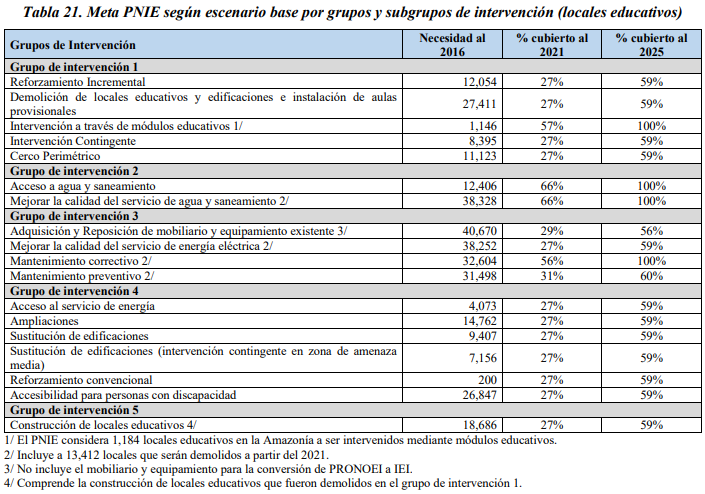

### 10.2 Exportando data

In [54]:
df = pd.read_csv("data/procesadas/indicadores_PNIE.csv", 
                 dtype={'codlocal': str})
bd = pd.read_stata('data/LE_BasePr_PNIE.dta')
codlocal(bd, 'id_local', 'codlocal')

df = pd.merge(df, bd[['codlocal', 'departamento', 'provincia', 'distrito', 
                      'area_sig', 'clima']],
              on='codlocal', how='left', indicator=True)
freq(df, '_merge')
df.drop(columns=['_merge'], inplace=True)

df = df[['codlocal', 
         'departamento', 'provincia', 'distrito', 'area_sig', 'clima',
         'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
         'GI2_1', 'GI2_2', 
         'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 
         'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4', 
         'GI5_1', 'GI5_2', 
         'GI1', 'GI2', 'GI3', 'GI4', 'GI5',
         'ET1', 'ET2', 
         'OE1', 'OE2', 'OE4', 
         'RF1', 'RF2_matri', 'matricula']]
df_PNIE = df.copy()

              Freq   (%)
_merge                  
both        42,331  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       42,331  100% 



C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\3871407433.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[newvar] = df[oldvar].astype(str).str.zfill(6)


In [55]:
anios = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

for anio in anios:
    df = pd.read_csv(f"data/procesadas/indicadores_{anio}.csv", 
                     dtype={'codlocal': str})
    bd = pd.read_stata(f"data/LE_BasePr_{anio}.dta")
    codlocal(bd, 'cod_local', 'codlocal')

    df = pd.merge(df, bd[['codlocal', 'region', 'prov', 'dist', 'nom_local', 
                          'urbano', 'rural', 'clima']],
                on='codlocal', how='left', indicator=True)
    freq(df, '_merge')

    df['area_censal'] = np.where(df['urbano'] == 1, 'Urbano', 'Rural')
    df.drop(columns=['_merge', 'urbano', 'rural'], inplace=True)

    df = df[['codlocal', 
            'region', 'prov', 'dist', 'nom_local', 'area_censal', 'clima',
            'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
            'GI2_1', 'GI2_2', 
            'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 
            'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4', 
            'GI5_1', 'GI5_2', 
            'GI1', 'GI2', 'GI3', 'GI4', 'GI5',
            'ET1', 'ET2', 
            'OE1', 'OE2', 'OE4', 
            'RF1', 'RF2_matri', 'matricula']]

    locals()[f'df_{anio}'] = df.copy()

C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\3871407433.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[newvar] = df[oldvar].astype(str).str.zfill(6)


              Freq   (%)
_merge                  
both        54,973  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       54,973  100% 



C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\3871407433.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[newvar] = df[oldvar].astype(str).str.zfill(6)


              Freq   (%)
_merge                  
both        55,058  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,058  100% 



C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\724140134.py:6: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  bd = pd.read_stata(f"data/LE_BasePr_{anio}.dta")
C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\3871407433.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[newvar] = df[oldvar].astype(str).str.zfill(6)


              Freq   (%)
_merge                  
both        55,211  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,211  100% 



C:\Users\diplan27.MINEDU\AppData\Local\Temp\ipykernel_19988\3871407433.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[newvar] = df[oldvar].astype(str).str.zfill(6)


              Freq   (%)
_merge                  
both        55,304  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,304  100% 

              Freq   (%)
_merge                  
both        55,358  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,358  100% 

              Freq   (%)
_merge                  
both        55,425  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,425  100% 

              Freq   (%)
_merge                  
both        55,602  100%
left_only        0  0.0%
right_only       0  0.0%
TOTAL       55,602  100% 



In [56]:
def coerce_types_int_and_str(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    if len(num_cols):
        out[num_cols] = (out[num_cols]
                         .round(0)            # redondea por si hay floats
                         .astype("Int64"))    # enteros con soporte de NA
    # lo no numérico lo paso a string "pandas"
    other_cols = out.columns.difference(num_cols)
    if len(other_cols):
        out[other_cols] = out[other_cols].astype("string")
    return out

In [57]:
anios = ['PNIE', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

ind = pd.DataFrame()

for anio in anios:
    df = pd.read_csv(f"data/procesadas/indicadores_{anio}.csv",
                    dtype={'codlocal': str})

    sum_cols  = ['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
                'GI2_1', 'GI2_2', 
                'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 
                'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4', 
                'GI5_1', 'GI5_2',
                'GI1', 'GI2', 'GI3', 'GI4', 'GI5',
                'ET1', 'ET2', 'OE1', 'OE2', 'OE4', 
                'RF1', 'RF2_matri', 'matricula']
    count_cols = ['GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5', 
                'GI2_1', 'GI2_2', 
                'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 
                'GI4_1', 'GI4_2', 'GI4_3', 'GI4_4', 
                'GI5_1',
                'GI1', 'GI2', 'GI3', 'GI4', 'ET1', 'ET2', 'OE1', 'OE4', 'RF1']

    # Dimensionando a nivel de indicador
    res = {'codlocal': df['codlocal'].nunique()}
    sums = df[sum_cols].sum()
    res.update({f'{c}_num': float(sums[c]) for c in sum_cols})
    counts = df[count_cols].count()
    res.update({f'{c}_den': int(counts[c]) for c in count_cols})
    out_cols = (['codlocal']
                + [f'{c}_num'   for c in sum_cols]
                + [f'{c}_den' for c in count_cols])
    out = pd.DataFrame([res])[out_cols]
    out.rename(columns={'codlocal': 'codlocal_num',
                        'RF2_matri_num': 'RF2_num',
                        'matricula_num': 'RF2_den'}, inplace=True)
    for c in count_cols:
        out[c] = out[f'{c}_num'] / out[f'{c}_den'] * 100
    out['RF2'] = out['RF2_num'] / out['RF2_den'] * 100
    num_bases = {c[:-4] for c in out.columns if c.endswith('_num')}
    den_bases = {c[:-4] for c in out.columns if c.endswith('_den')}
    bases = sorted(num_bases | den_bases)
    rows = []
    for _, row in out.iterrows():
        for b in bases:
            rows.append({
                'indicador': b,
                'num':   row.get(f'{b}_num', pd.NA),
                'den':   row.get(f'{b}_den', pd.NA),
                'valor': row.get(b, pd.NA)  # la columna sin sufijo
            })
    out = pd.DataFrame(rows)
    out[['num', 'den']] = out[['num', 'den']].astype('Int64')
    out.loc[out['valor'].isna(), 'valor'] = out['num']

    # Ordenando
    orden_manual = ['codlocal']
    sub_gi = sorted([x for x in out['indicador'].unique() if 
                    re.match(r'^GI\d+_\d+', x)])
    gi_global = sorted([x for x in out['indicador'].unique() if 
                        re.match(r'^GI\d+$', x)])
    otros = ['ET1', 'ET2', 'OE1', 'OE2', 'OE4', 'RF1', 'RF2']
    orden_final = orden_manual + sub_gi + gi_global + otros
    out['indicador'] = pd.Categorical(out['indicador'], categories=orden_final, 
                                    ordered=True)
    out = out.sort_values('indicador').reset_index(drop=True)

    # Añadiendo año en las columnas
    out.rename(columns={'num': f'num_{anio}', 
                        'den': f'den_{anio}', 
                        'valor': f'valor_{anio}'}, 
            inplace=True)
    
    # Concatenar al dataframe final
    ind = pd.merge(ind, out, on=['indicador'], how='left') if not ind.empty \
        else out

ind.iloc[:, 1:] = ind.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').astype('float')
df_ind = ind.copy()

In [66]:
anios = ['resumen2', 'PNIE', '2019', '2020', '2021', '2022', '2023', '2024', 
         '2025', 'resumen1', 'ind']
dfs = {anio: globals()[f"df_{anio}"].copy() for anio in anios}

outfile = "IS-Evaluación PNIE (v0).xlsx"
with pd.ExcelWriter(outfile, engine="xlsxwriter") as writer:
    for anio, df in dfs.items():
        if df.equals(df_ind):
            df.to_excel(writer, sheet_name=anio, 
                          index=False, startrow=0, startcol=0)
        else:
            df2 = coerce_types_int_and_str(df)

            # escribe desde A4 (fila 4 = startrow 3), incluyendo encabezados
            df2.to_excel(writer, sheet_name=anio, 
                        index=False, startrow=3, startcol=0)
        print(anio)


resumen2
PNIE
2019
2020
2021
2022
2023
2024
2025
resumen1
ind


### 10.3 Graficos

In [11]:
mapa = {
    'codlocal': 'Número de locales educativos', 
    'GI1_1': '%', 'GI1_2': '%', 'GI1_3': '%', 'GI1_4': '%', 'GI1_5': '%',
    'GI2_1': '%', 'GI2_2': '%', 
    'GI3_1': '%', 'GI3_2': '%', 'GI3_3': '%', 'GI3_4': '%', 
    'GI4_1': '%', 'GI4_2': '%', 'GI4_3': '%', 'GI4_4': '%', 
    'GI5_1': '%', 'GI5_2': 'Número de locales educativos', 
    'GI1': '%', 'GI2': '%', 'GI3': '%', 'GI4': '%', 
    'GI5': 'Número de locales educativos',
    'ET1': '%', 'ET2': '%', 
    'OE1': '%', 'OE2': 'Matrícula de estudiantes', 'OE4': '%', 
    'RF1': '%', 'RF2': '%'
}

metas = {
    'GI1_1': {'2021': 27, '2025': 59}, 'GI1_2': {'2021': 27, '2025': 59}, 
    'GI1_3': {'2021': 27, '2025': 59}, 'GI1_4': {'2021': 57, '2025': 100}, 
    'GI1_5': {'2021': 27, '2025': 59},
    'GI2_1': {'2021': 66, '2025': 100}, 'GI2_2': {'2021': 66, '2025': 100}, 
    'GI3_1': {'2021': 27, '2025': 59}, 'GI3_2': {'2021': 29, '2025': 56}, 
    'GI3_3': {'2021': 56, '2025': 100}, 'GI3_4': {'2021': 31, '2025': 60}, 
    'GI4_1': {'2021': 27, '2025': 59}, 'GI4_2': {'2021': 27, '2025': 59}, 
    'GI4_3': {'2021': 27, '2025': 59}, 'GI4_4': {'2021': 27, '2025': 59},
    'GI5_1': {'2021': 27, '2025': 59} 
}

plt.rcParams["font.family"] = "Arial"

In [12]:
def _fmt_val(col, val, mapa):
    unidad = mapa.get(col, "")
    if pd.isna(val):
        return ""
    if unidad == "%":
        return f"{val:.1f}"
    if unidad in {"Número de locales educativos", "Matrícula de estudiantes"}:
        return f"{val:,.0f}"
    return f"{val:,.0f}"

In [94]:
data['aux1']

0    <NA>
1    32.0
2    -0.1
3     0.2
4     0.0
5    -0.0
6    -0.0
7    -0.0
Name: aux1, dtype: Float64

In [95]:
data['aux1'] >= cambio

0     <NA>
1     True
2    False
3     True
4    False
5    False
6    False
7    False
Name: aux1, dtype: boolean

In [98]:
cambio = 0.2
data = ind.copy()
data = data[data['GI5'].notna()].copy()
data['shift'] = data['GI5'].shift(1)

data['aux1'] = (data['GI5'] / data['GI5'].shift(1)) - 1
data['aux2'] = (data['GI5'] / data['GI5'].shift(-1)) - 1
data['pre'] = np.where(data['aux1'].astype(float) >= cambio, 'U', 
                       np.where(data['aux1'].astype(float) <= -cambio, 
                                'D', 'S'))
data['post'] = np.where(data['aux2'].astype(float) >= cambio, 'D', 
                        np.where(data['aux2'].astype(float) <= -cambio, 
                                 'U', 'S'))

data[['anio', 'GI5', 'shift', 'aux1', 'aux2', 'pre', 'post']]

,anio,GI5,shift,aux1,aux2,pre,post
0,PNIE,121,<NA>,<NA>,-1.0,S,U
1,2019,3994,121,32.0,0.1,U,S
2,2020,3669,3994,-0.1,-0.2,S,S
3,2021,4483,3669,0.2,-0.0,U,S
4,2022,4695,4483,0.0,0.0,S,S
5,2023,4558,4695,-0.0,0.0,S,S
6,2024,4538,4558,-0.0,0.1,S,S
7,2025,4315,4538,-0.0,<NA>,S,S


In [1]:
def plot_serie_tiempo(df, col, color="#000000", mapa=mapa, metas=metas,
                      fuente=14, ruta='', cambio=0.5):

    if mapa is None: mapa = {}
    if metas is None: metas = {}

    # Copia y limpieza básica
    data = df.copy()
    data = data[data[col].notna()].copy()
    if col in data.columns:
        data['aux1'] = (data[col] / data[col].shift(1)) - 1
        data['aux2'] = (data[col] / data[col].shift(-1)) - 1
    else:
        data['aux1'] = 0.0
        data['aux2'] = 0.0
    data['pre'] = np.where(data['aux1'].astype(float) >= cambio, 'U', 
                        np.where(data['aux1'].astype(float) <= -cambio, 
                                 'D', 'S'))
    data['post'] = np.where(data['aux2'].astype(float) >= cambio, 'D', 
                            np.where(data['aux2'].astype(float) <= -cambio, 
                                     'U', 'S'))

    # Eje X categórico como strings
    data["anio"] = data["anio"].astype(str)
    x = data["anio"].tolist()
    y = data[col].values

    fig, ax = plt.subplots(figsize=(10, 5))
    # Serie principal (marcador cuadrado)
    ax.plot(x, y, marker="s", color=color, linewidth=2)

    # Etiquetas de la serie principal
    for xi, yi in zip(x, y):
        if pd.notna(yi):
            pre = data.loc[data['anio'] == xi, 'pre'].values[0]
            post = data.loc[data['anio'] == xi, 'post'].values[0]

            if (pre == 'U') and (post == 'D'): offset = 15
            elif (pre == 'U') and (post == 'U'): offset = 15
            elif (pre == 'U') and (post == 'S'): offset = 15
            elif (pre == 'D') and (post == 'D'): offset = 15
            elif (pre == 'D') and (post == 'U'): offset = -20
            elif (pre == 'D') and (post == 'S'): offset = -20
            elif (pre == 'S') and (post == 'U'): offset = -20
            elif (pre == 'S') and (post == 'D'): offset = 15
            else: offset = 15
            ax.annotate(
                _fmt_val(col, yi, mapa),
                (xi, yi),
                textcoords="offset points",
                xytext=(0, offset),
                ha="center",
                fontsize=fuente
            )

    # ── Metas como líneas verticales punteadas (pastel) ─────────────────
    handles = []
    labels  = []
    metas_col = metas.get(col, None)

    # mapea las categorías a posiciones
    pos_map = {lab: i for i, lab in enumerate(x)}

    if metas_col:
        m2021 = metas_col.get('2021', metas_col.get(2021, None))
        m2025 = metas_col.get('2025', metas_col.get(2025, None))

        # Colores pastel y estilo punteado
        col_2021 = "#0A518F"
        col_2025 = "#BF0411"
        ls = (0, (4, 4))      # punteado suave

        # Línea vertical en 2021
        if ('2021' in x) and (m2021 is not None):
            # usa la posición categórica de '2021'
            h1 = ax.axhline(m2021, color=col_2021, linestyle=ls, linewidth=2, 
                            label="Meta PNIE al 2021")
            handles.append(h1); labels.append("Meta PNIE al 2021")
            ax.annotate(f"{m2021:.0f}", xy=(0, m2021), xytext=(-25, 5), 
                        textcoords="offset points", fontsize=fuente)

        # Línea vertical en 2025
        if ('2025' in x) and (m2025 is not None):
            h2 = ax.axhline(m2025, color=col_2025, linestyle=ls, linewidth=2, 
                            label="Meta PNIE al 2025")
            handles.append(h2); labels.append("Meta PNIE al 2025")
            ax.annotate(f"{m2025:.0f}", xy=(0, m2025), xytext=(-25, 5), 
                        textcoords="offset points", fontsize=fuente)

    # ── Estilo del gráfico ─────────────────────────────────────────────
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_visible(True)

    ax.set_xlabel("Año", fontsize=fuente)
    ax.set_ylabel(mapa.get(col, ""), fontsize=fuente)
    ax.grid(False)

    # ticks X como categorías originales
    ax.set_xticks(range(len(x)))
    ax.set_xticklabels(x, rotation=0, fontsize=fuente)

    # ocultar eje Y
    ax.set_yticks([])
    ax.set_yticklabels([])

    # leyenda (si hay metas)
    if handles:
        ax.legend(handles=handles, labels=labels, loc="upper right", 
                  fontsize=fuente, frameon=False)

    # margen en Y para evitar traslapes
    ymin, ymax = ax.get_ylim()
    rng = ymax - ymin if ymax > ymin else 1.0
    ax.set_ylim(ymin - 0.2 * rng, ymax + 0.2 * rng)

    plt.tight_layout()

    # Guardar (alta resolución + transparente)
    if ruta:
        ruta_graf = ruta + f"/Gráfico_{col}.png"
        plt.savefig(ruta_graf, dpi=600, bbox_inches='tight', transparent=True)

    plt.show();

plot_serie_tiempo(ind, 'ET2', "#0A518FFF", mapa, metas, 
                  ruta='Gráficos')

NameError: name 'mapa' is not defined

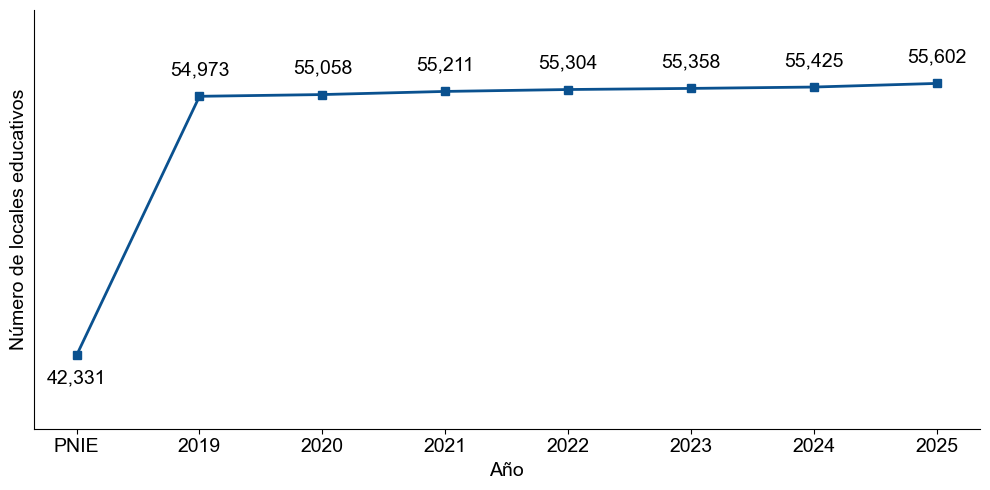

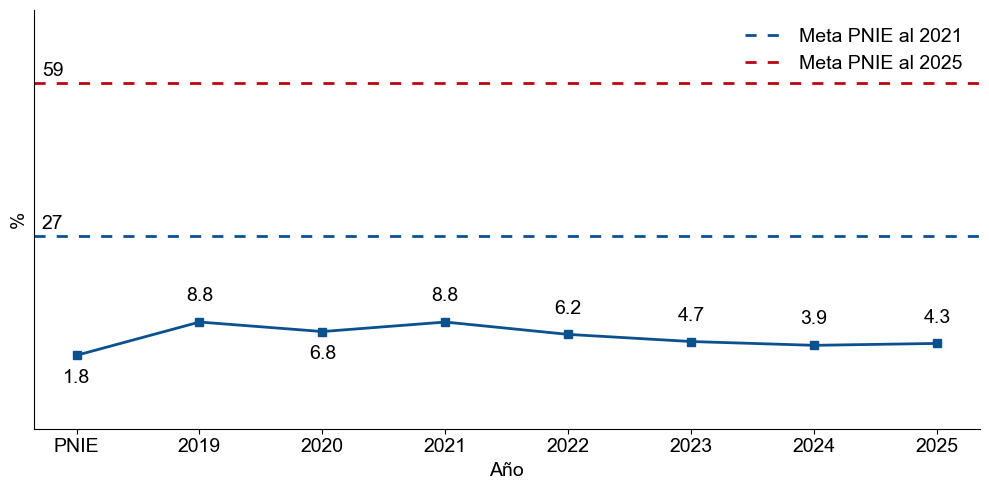

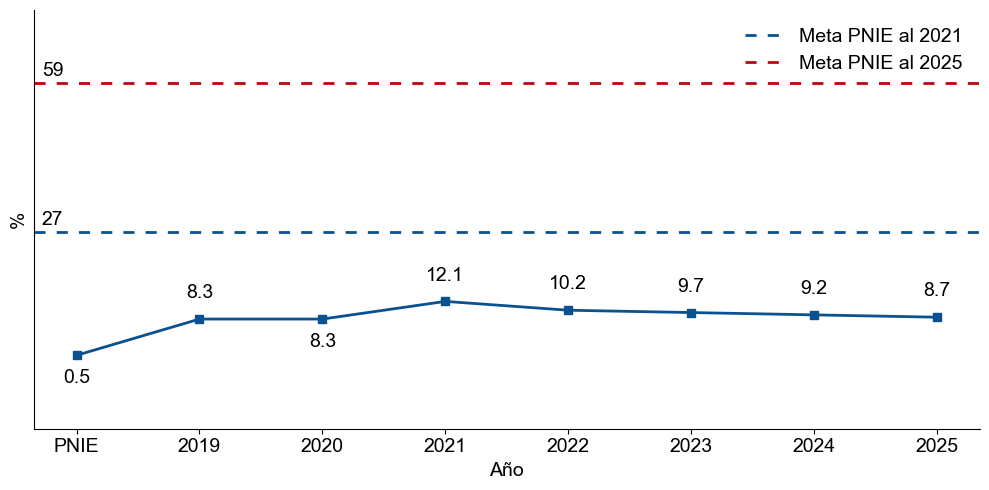

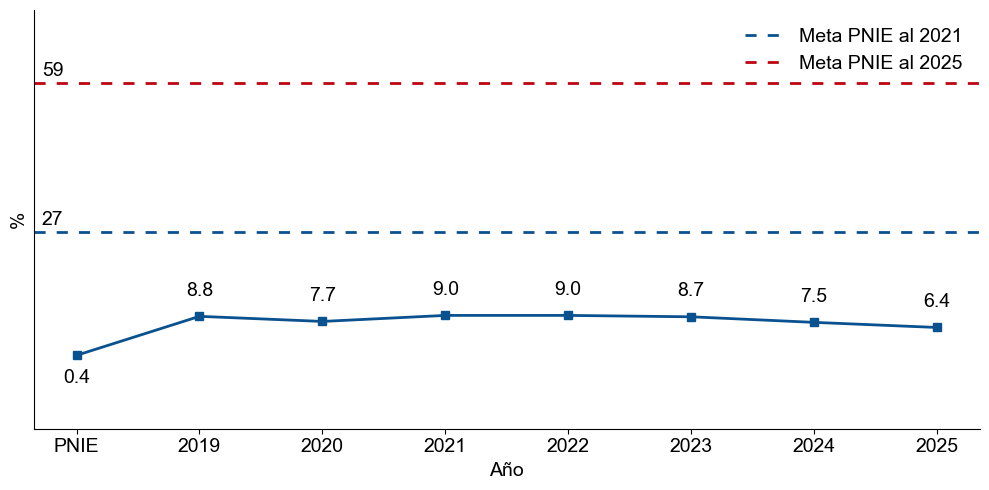

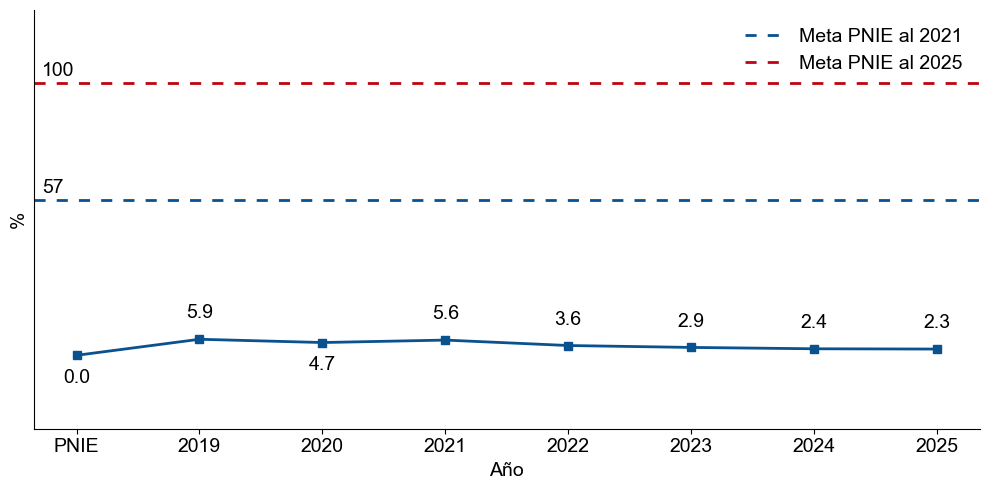

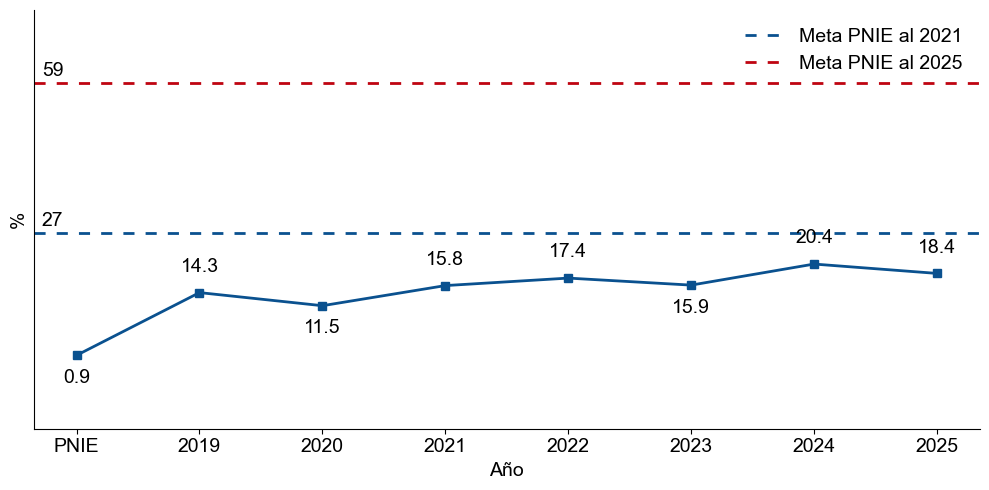

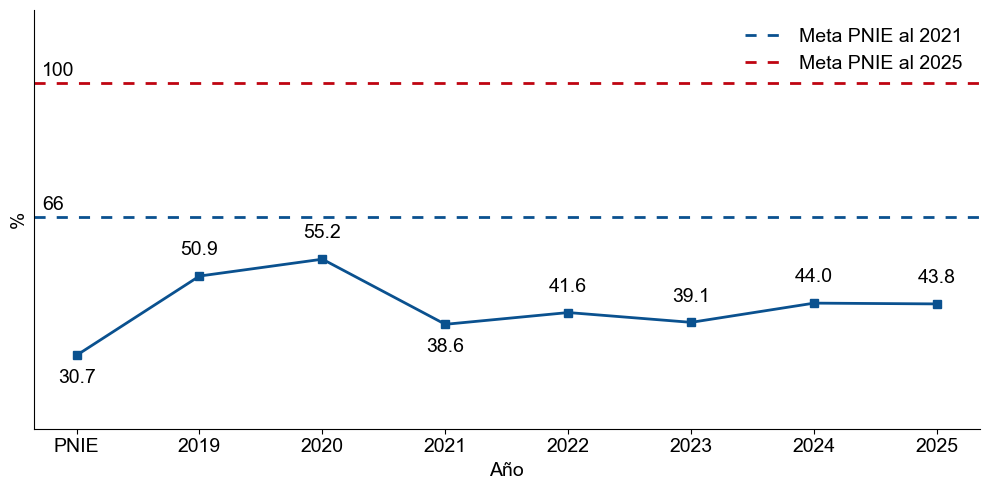

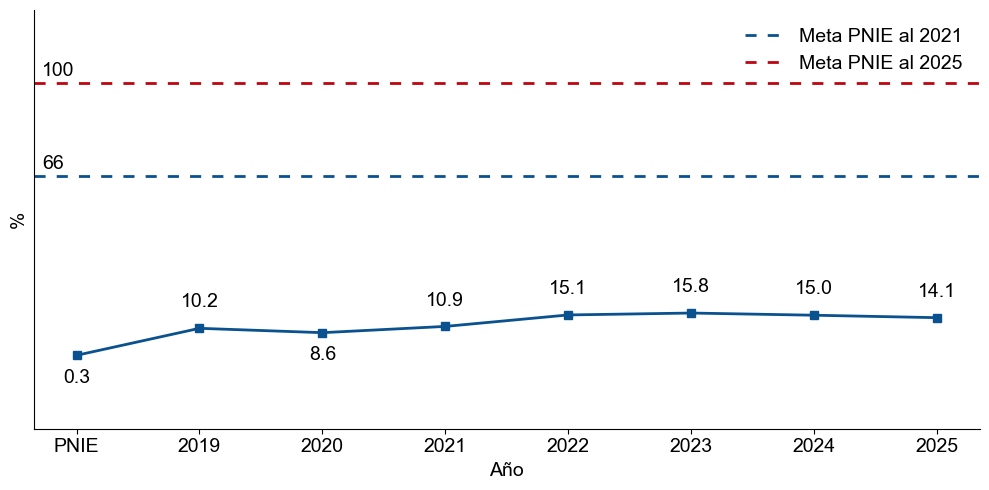

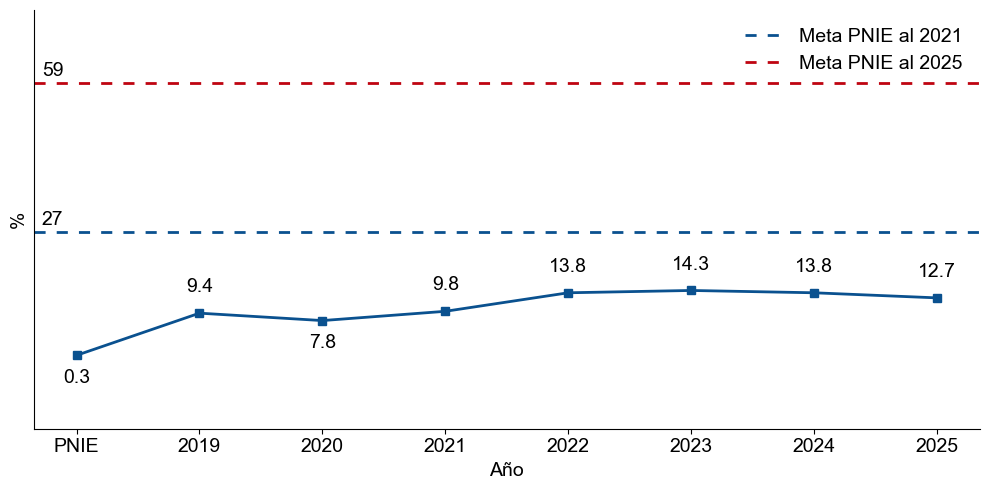

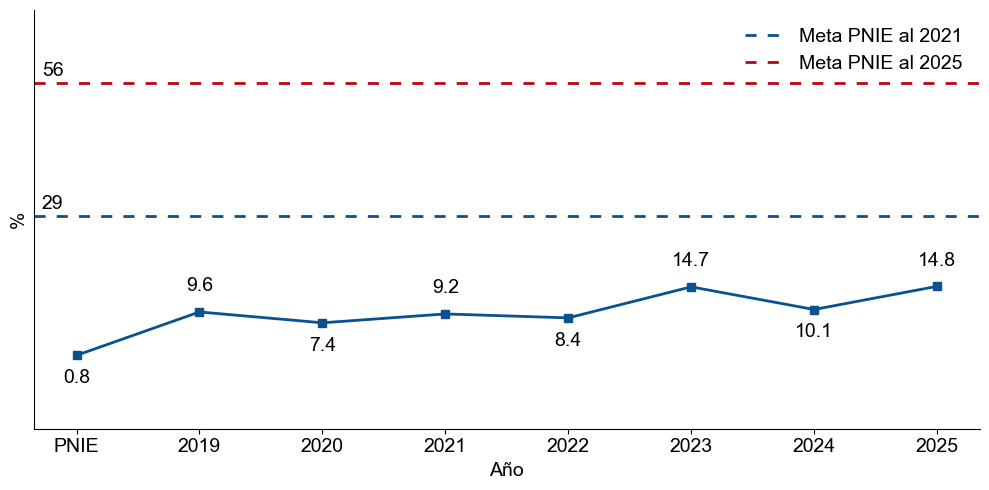

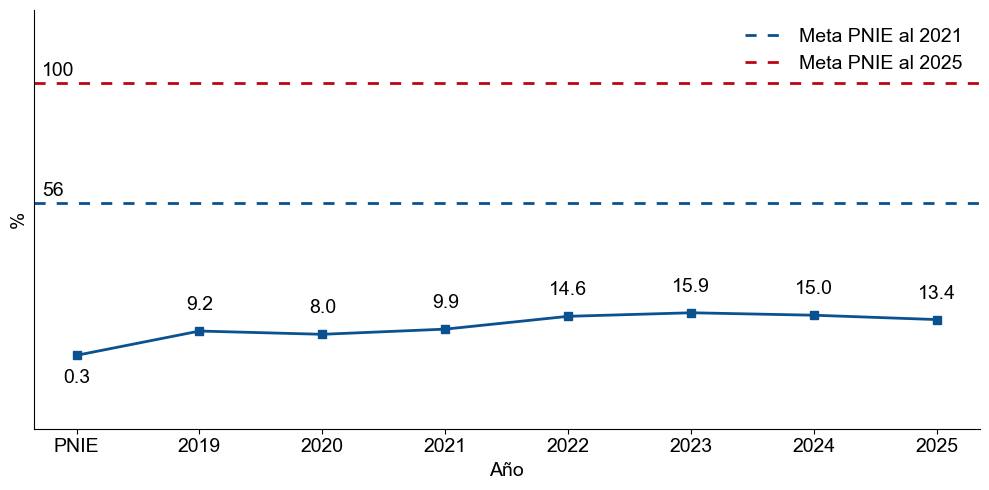

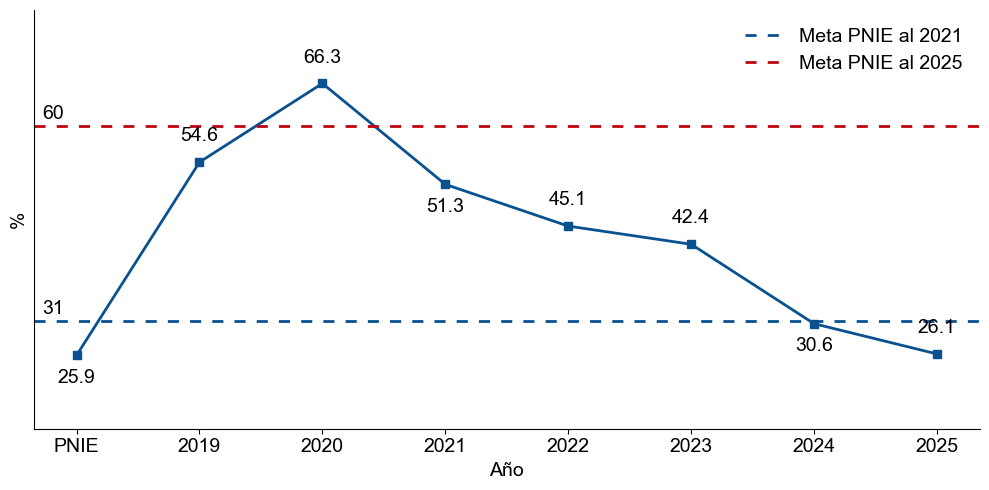

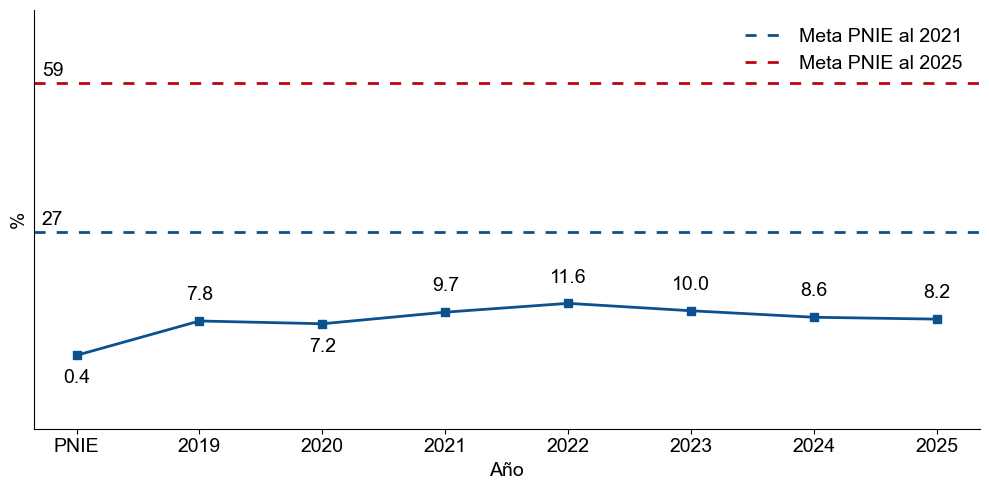

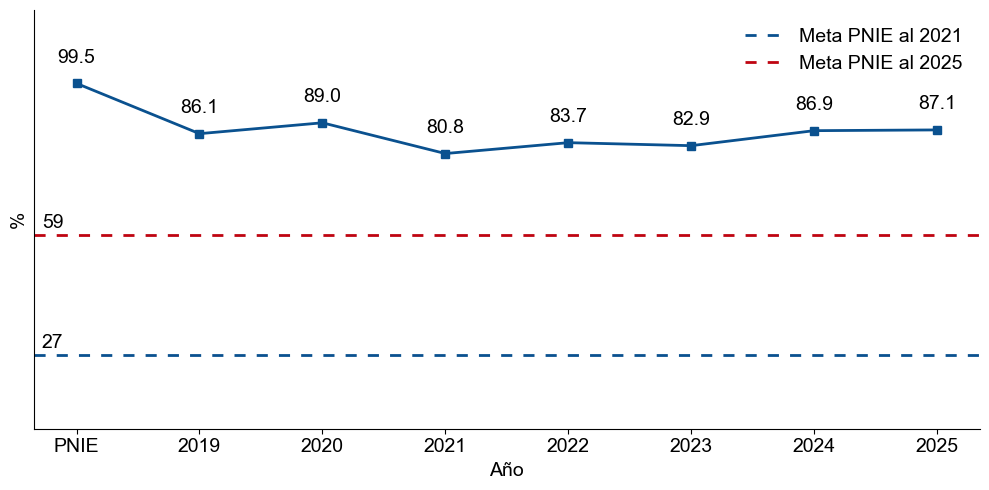

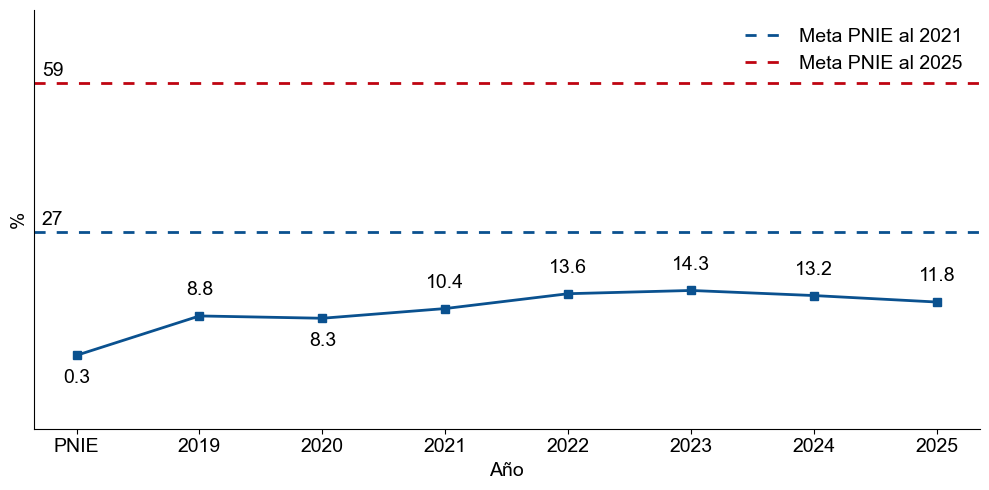

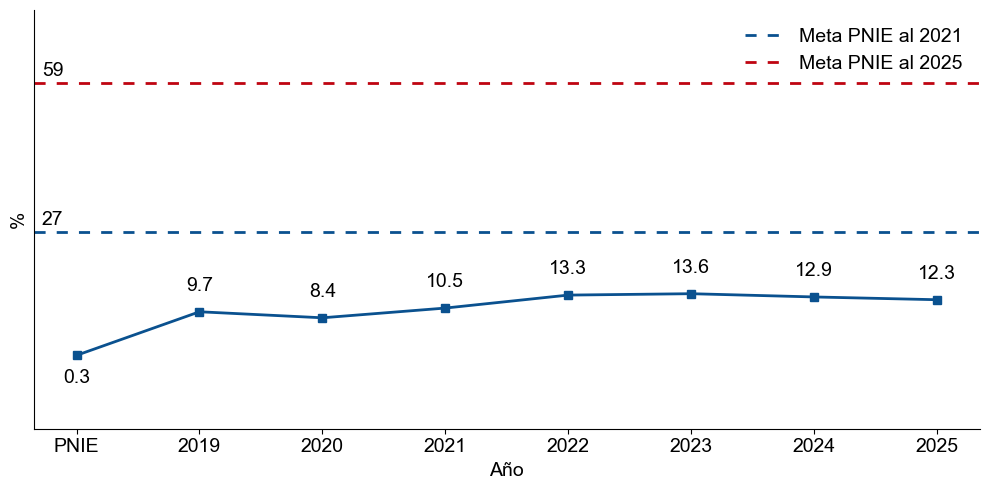

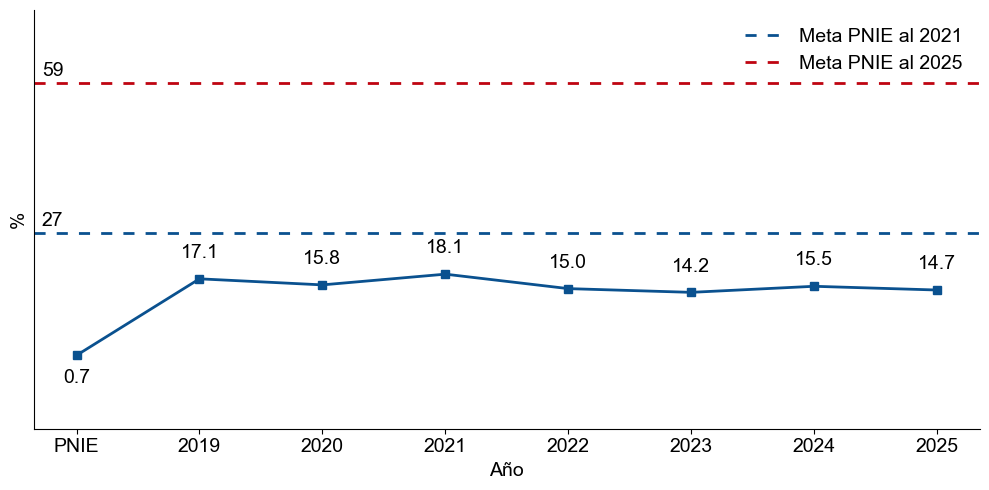

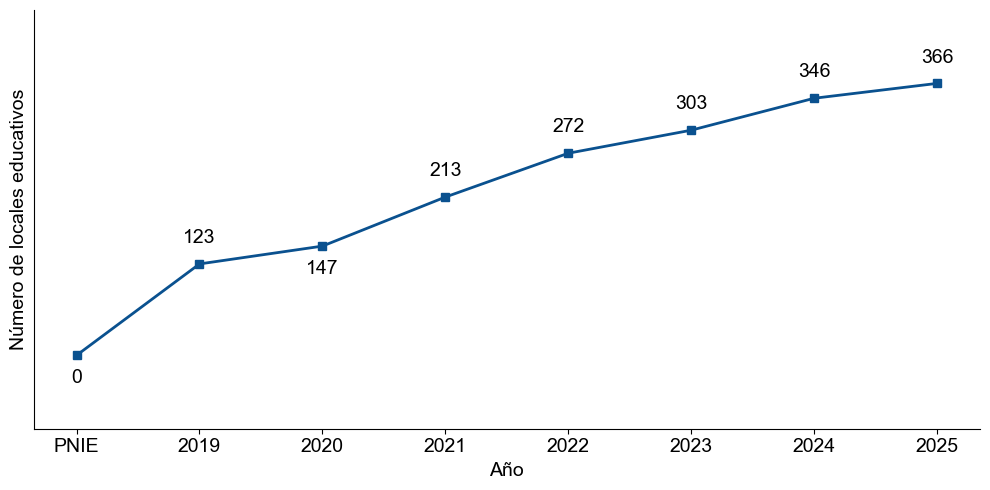

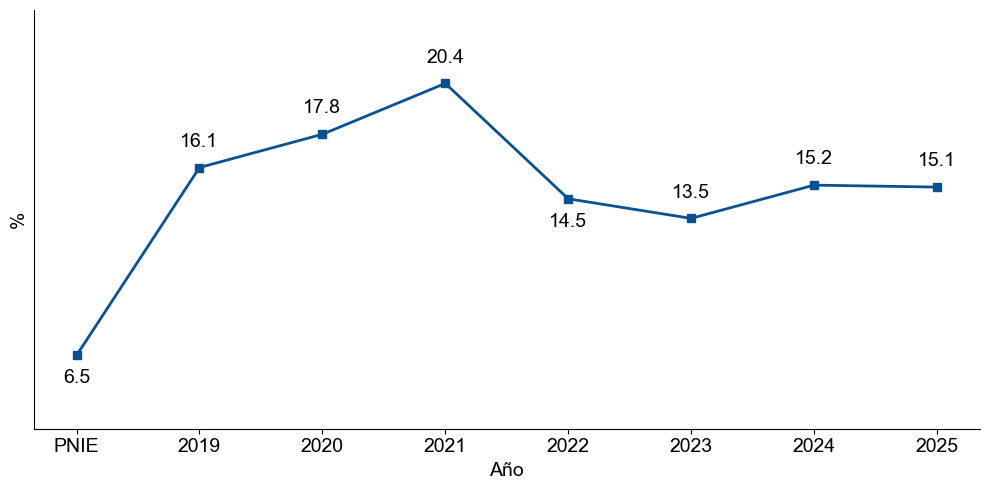

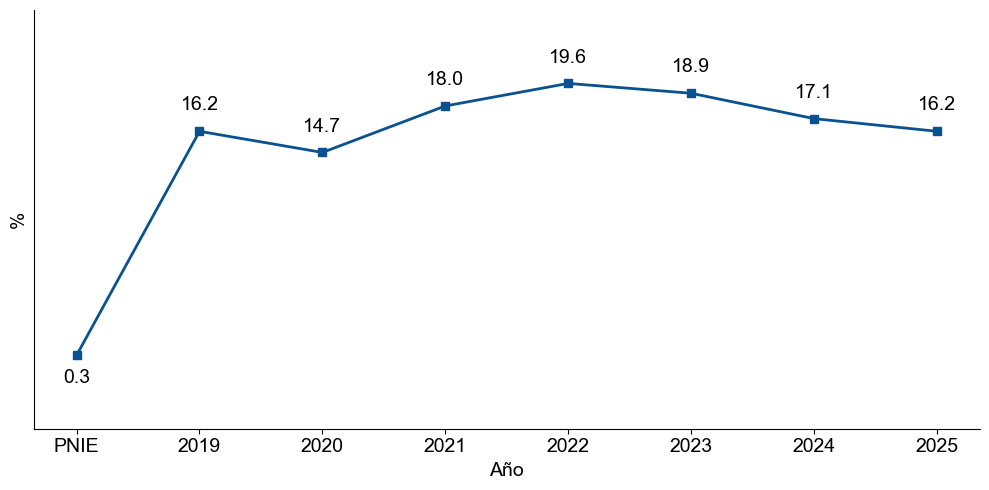

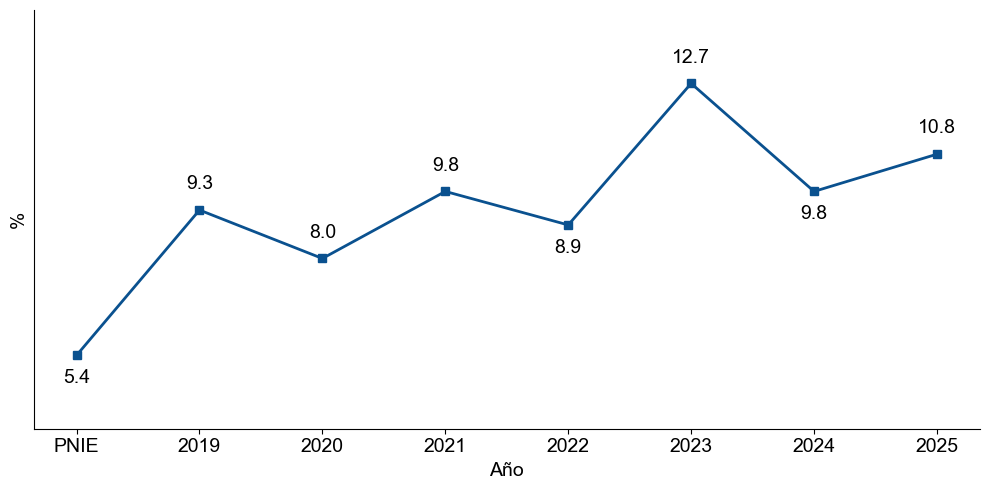

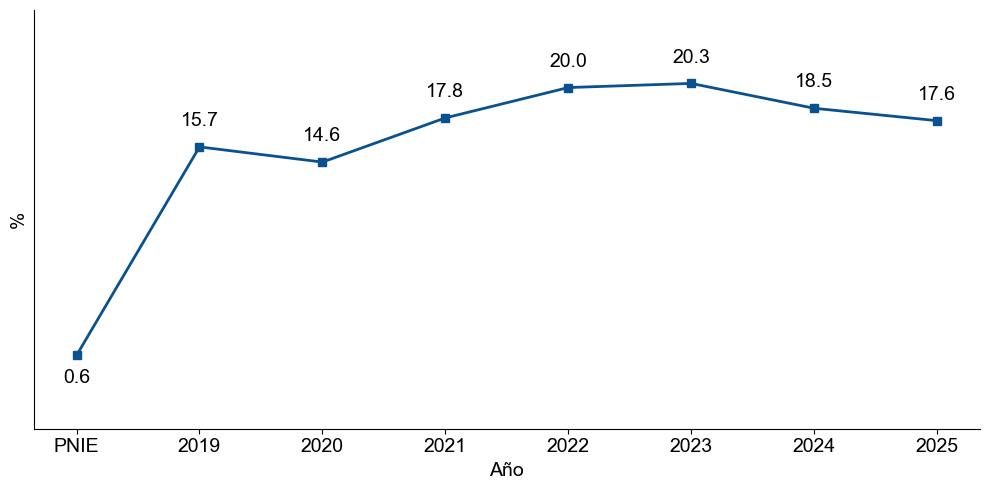

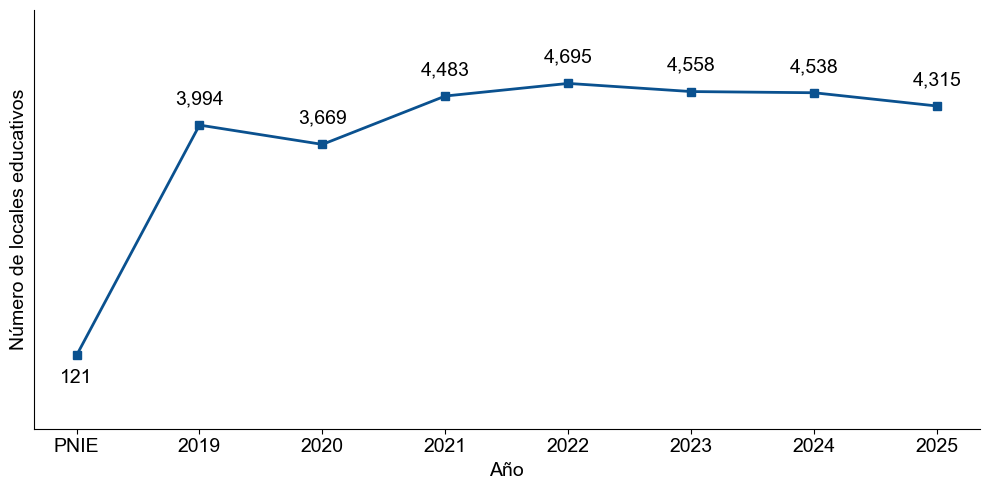

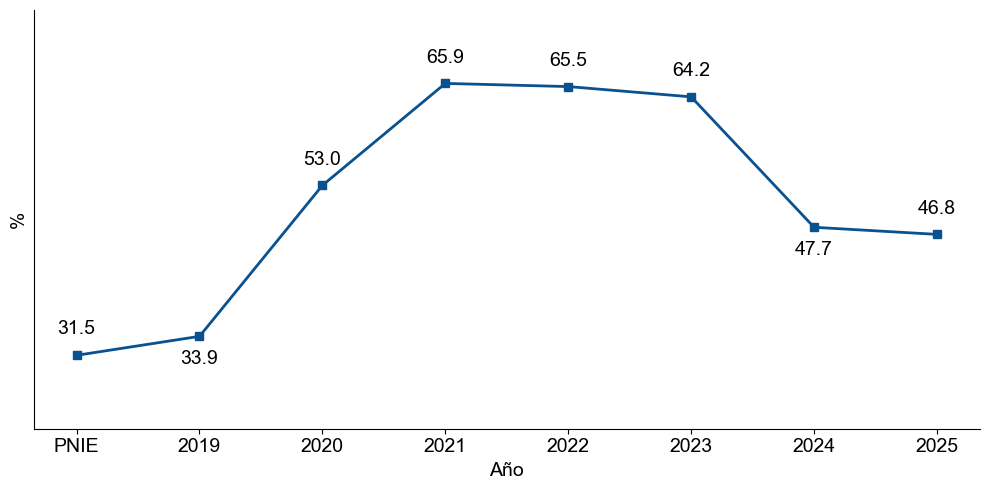

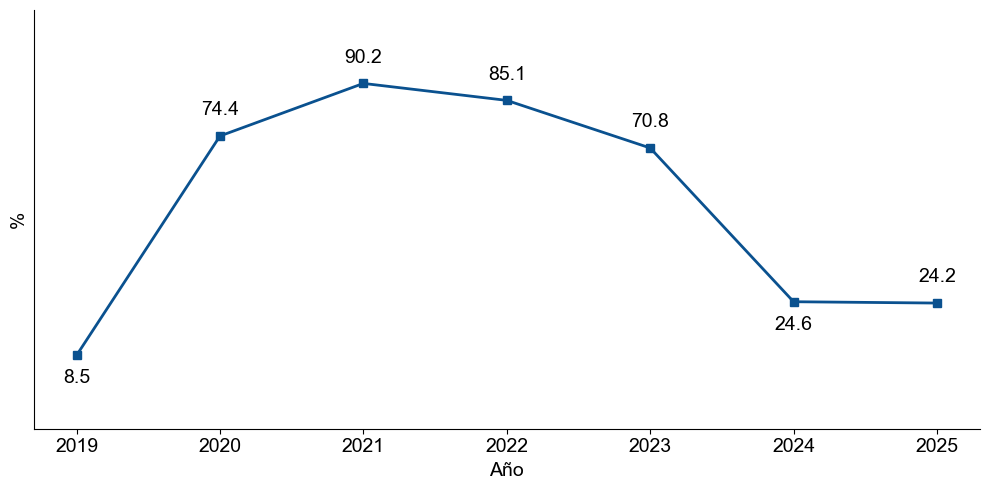

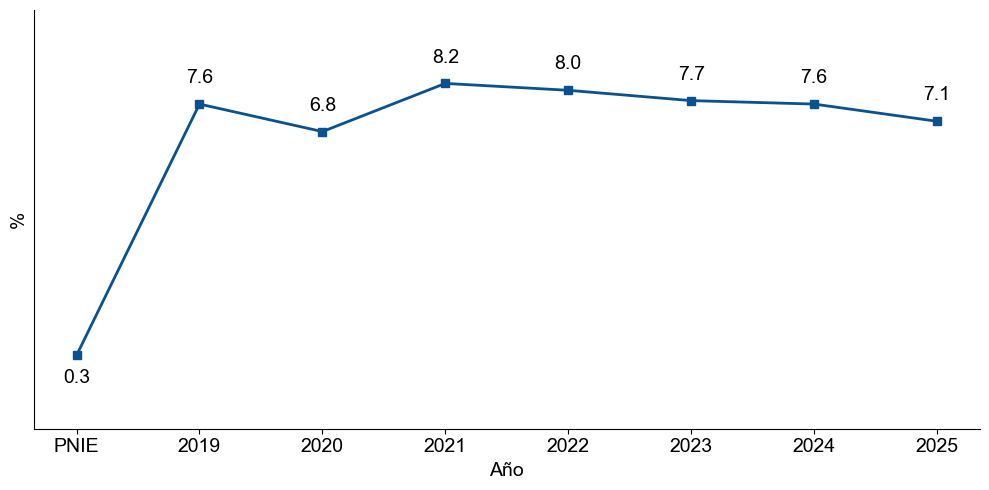

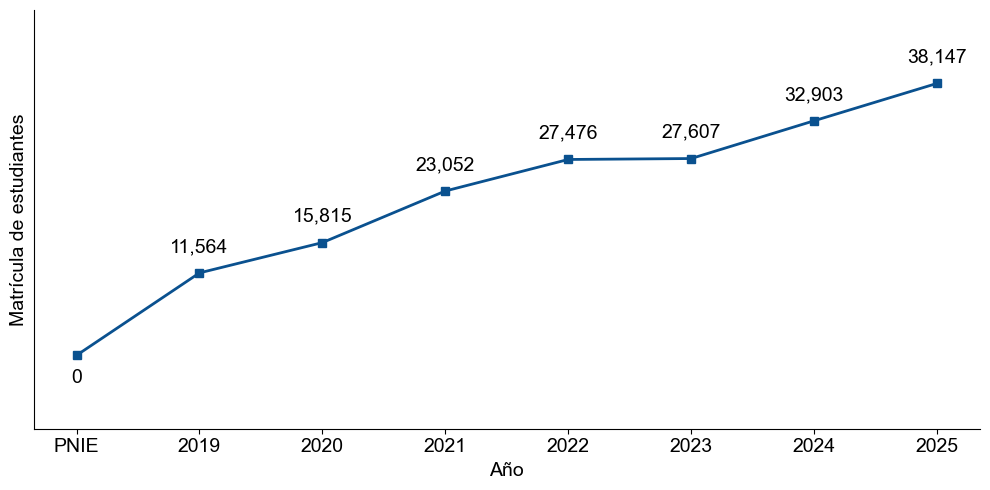

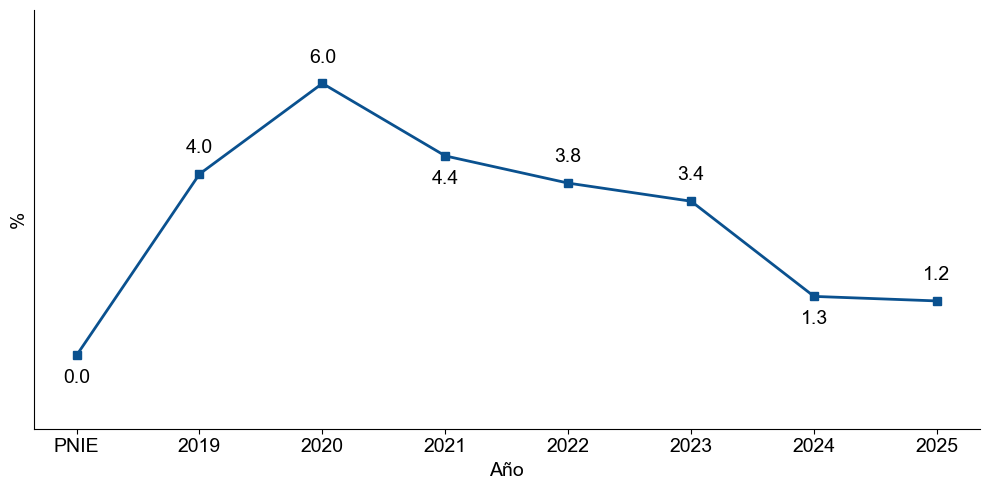

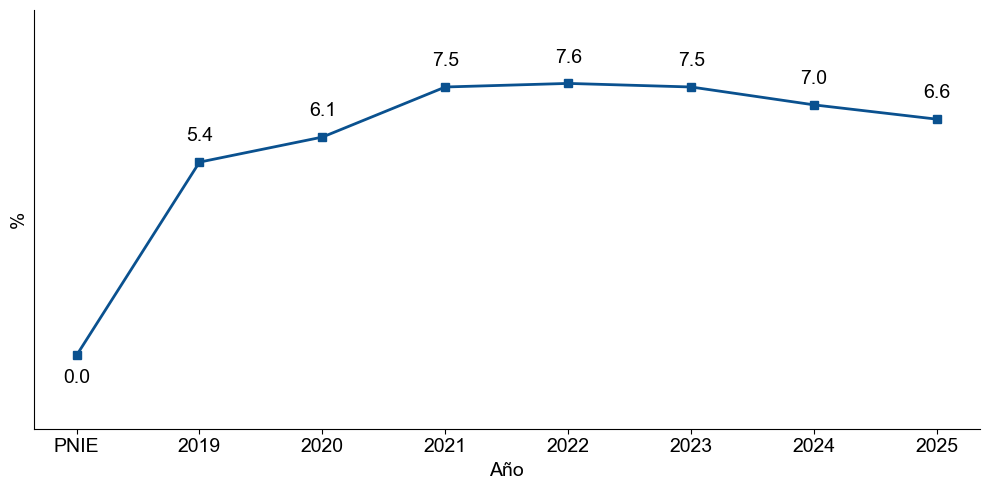

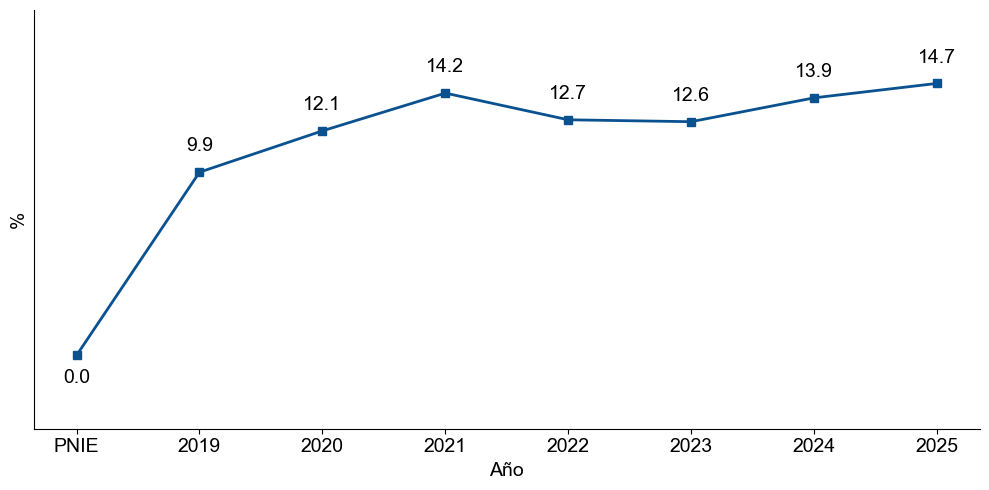

In [109]:
inds = ['codlocal', 'GI1_1', 'GI1_2', 'GI1_3', 'GI1_4', 'GI1_5',
       'GI2_1', 'GI2_2', 'GI3_1', 'GI3_2', 'GI3_3', 'GI3_4', 'GI4_1', 'GI4_2',
       'GI4_3', 'GI4_4', 'GI5_1', 'GI5_2', 'GI1', 'GI2', 'GI3', 'GI4', 'GI5',
       'ET1', 'ET2', 'OE1', 'OE2', 'OE4', 'RF1', 'RF2']

for x in inds:
    plot_serie_tiempo(ind, x, '#0A518F', mapa, metas, 
                      ruta='Gráficos', cambio=0.2)

In [ ]:
# aux_0 = pd.read_csv('data/procesadas/intervenciones_TOTAL.csv', 
#                     dtype={'codlocal': str, 'CUI': str})

In [ ]:
# # Observando fuentes de información de intervenciones
# aux = aux_0.copy()

# ind = 'GI4_4'
# aux = aux[aux[ind] == 1]
# fuentes = aux['fuente'].unique().tolist()

# separados = []
# for item in fuentes:
#     partes = [p.strip() for p in item.split(" / ")]
#     separados.extend(partes)

# resultado = list(dict.fromkeys(separados))
# resultado.sort()
# for r in resultado:
#     print(r)

ANIN
ARCC
Análisis BI GN del EV-PNIE
Análisis BI GR/GL del EV-PNIE
Análisis FUR y emblematicos GR/GL del EV-PNIE
Análisis IOARR GN del EV-PNIE
Análisis IOARR GR/GL del EV-PNIE
FONCODES
PRONIED-UGEO
PRONIED-UGM-ACCESIBILIDAD
PRONIED-UGM-PREVENTIVO
PRONIED-UGME-ME
PRONIED-UGME-SM
PRONIED-UGSC-ASITEC/SIAT
PRONIED-UGSC-SyM


In [ ]:
df[df['codlocal'].duplicated(keep=False)].sort_values(by='codlocal')